In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os
from sklearn.model_selection import StratifiedGroupKFold

# ------------------ 1. Загрузка данных из обработанного CSV ------------------
DATA_PATH = 'data/processed/siddha_processed.csv'
df = pd.read_csv(DATA_PATH)  # колонки: user_id, activity, timestamp, gyro_x, gyro_y, gyro_z, acc_x, acc_y, acc_z

# Убедимся, что нет пропусков и нулевых временных меток (на всякий случай)
df = df.dropna()
#df = df[df['timestamp'] != 0]

# Сортируем по пользователю и времени (уже должно быть, но гарантируем)
df = df.sort_values(['user_id', 'activity', 'timestamp']).reset_index(drop=True)

# ------------------ 2. Создание окон ------------------
WINDOW_SIZE = 200
STEP = 100  # перекрытие 50%

# Признаки: все, кроме user_id, activity, timestamp
feature_cols = ['gyro_x', 'gyro_y', 'gyro_z', 'acc_x', 'acc_y', 'acc_z']

X_windows = []    # окна (WINDOW_SIZE, 6)
y_windows = []    # метки активности (уже числа 0..4)
user_windows = [] # ID пользователя для каждого окна

# Группируем по пользователю (данные внутри группы уже отсортированы по времени)
for user_id, group in df.groupby('user_id'):
    # Извлекаем массивы признаков и меток
    data = group[feature_cols].values        # shape (n, 6)
    activities = group['activity'].values    # shape (n,)
    
    n = len(data)
    if n < WINDOW_SIZE:
        continue  # недостаточно данных
    
    # Проходим по последовательности с шагом STEP
    for start in range(0, n - WINDOW_SIZE + 1, STEP):
        end = start + WINDOW_SIZE
        window_activities = activities[start:end]
        
        # Проверяем, что все активности в окне одинаковы
        if np.all(window_activities == window_activities[0]):
            X_windows.append(data[start:end])
            y_windows.append(window_activities[0])
            user_windows.append(user_id)

# Преобразуем в numpy
X_windows = np.array(X_windows)   # (num_windows, WINDOW_SIZE, 6)
y_windows = np.array(y_windows)   # (num_windows,)
user_windows = np.array(user_windows)

print(X_windows.shape)

print(f"Всего окон: {len(X_windows)}")
print(f"Уникальных пользователей с окнами: {len(np.unique(user_windows))}")

n_splits = 10
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
splits = list(sgkf.split(X_windows, y_windows, groups=user_windows))

def split_and_scale_by_indices(train_idx, val_idx, test_idx, X_windows, y_windows):
    """
    Принимает индексы для train/val/test, возвращает масштабированные данные.
    """
    X_train = X_windows[train_idx]
    y_train = y_windows[train_idx]
    X_val   = X_windows[val_idx]
    y_val   = y_windows[val_idx]
    X_test  = X_windows[test_idx]
    y_test  = y_windows[test_idx]

    print(f"Train windows: {len(X_train)}, Val windows: {len(X_val)}, Test windows: {len(X_test)}")

    # Масштабирование только по train
    X_train_flat = X_train.reshape(-1, 6)
    scaler = StandardScaler()
    scaler.fit(X_train_flat)

    def scale_data(X):
        orig_shape = X.shape
        X_flat = X.reshape(-1, 6)
        X_scaled = scaler.transform(X_flat)
        return X_scaled.reshape(orig_shape)

    X_train_scaled = scale_data(X_train)
    X_val_scaled   = scale_data(X_val)
    X_test_scaled  = scale_data(X_test)

    return X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test

(8504, 200, 6)
Всего окон: 8504
Уникальных пользователей с окнами: 51


In [2]:
# Train function

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
import os
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

def train_model(model, model_name, train_loader, val_loader, test_loader,
                num_epochs=50, lr=0.001, device='cuda', weights=None, save_dir='models'):
    """
    Обучение с динамическим обновлением вывода (Jupyter/Colab).
    Каждая эпоха перерисовывает: прогресс, лучший F1, графики потерь и F1.
    """
    os.makedirs(save_dir, exist_ok=True)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total trainable parameters: {total_params}")
    
    model = model.to(device)
    if weights is not None:
        weights = weights.to(device)
    
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': []
    }
    
    best_val_f1 = -1.0
    best_epoch = 0
    best_model_state = None

    epoch_bar = tqdm(range(1, num_epochs + 1), desc='Training', unit='epoch')
    for epoch in epoch_bar:
        # ---------- Train ----------
        model.train()
        train_losses = []
        train_preds = []
        train_labels = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.float().to(device)
            y_batch = y_batch.long().to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            preds = torch.argmax(outputs, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(y_batch.cpu().numpy())
        
        train_loss = np.mean(train_losses)
        train_acc = accuracy_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average='macro')
        
        # ---------- Validation ----------
        model.eval()
        val_losses = []
        val_preds = []
        val_labels = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.float().to(device)
                y_batch = y_batch.long().to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(y_batch.cpu().numpy())
        
        val_loss = np.mean(val_losses)
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average='macro')
        
        # Сохраняем историю
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        scheduler.step(val_loss)
        
        # Обновляем лучшую модель
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_model_state = model.state_dict().copy()
        
        # Сохраняем историю и проверяем лучший результат
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_model_state = model.state_dict().copy()
            # Выводим строку с лучшим значением (не ломает бар)
            tqdm.write(f'⭐ Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}')
        
        # Обновляем единственный прогресс-бар
        epoch_bar.set_postfix({
            'TL': f'{train_loss:.3f}',
            'VL': f'{val_loss:.3f}',
            'VF1': f'{val_f1:.3f}',
            'best VF1': f'{best_val_f1:.3f}' if best_val_f1 > -1 else '-',
            'best Epoch': f'{best_epoch}'
        })
    
    # ---------- Загрузка лучшей модели и сохранение ----------
    model.load_state_dict(best_model_state)
    torch.save(model.state_dict(), os.path.join(save_dir, f"{model_name}.pt"))

    # 2. Графики
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='train')
    ax1.plot(history['val_loss'], label='val')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(True)
        
    ax2.plot(history['train_f1'], label='train')
    ax2.plot(history['val_f1'], label='val')
    ax2.set_title('F1 (macro)')
    ax2.legend()
    ax2.grid(True)
        
    plt.tight_layout()
    plt.show()
    
    # ---------- Тест (финальный вывод после обучения) ----------
    #clear_output(wait=True)  # очищаем последний вывод с графиками
    print(f"Training complete. Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}")
    print(f"Model saved to {save_dir}/{model_name}.pt")
    
    model.eval()
    test_preds = []
    test_labels = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.float().to(device)
            y_batch = y_batch.long().to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)
            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(y_batch.cpu().numpy())
    
    print("\n========== Test Set Evaluation ==========")
    print(classification_report(test_labels, test_preds, digits=4))
    test_acc = accuracy_score(test_labels, test_preds)
    test_f1_macro = f1_score(test_labels, test_preds, average='macro')
    test_precision_macro = precision_score(test_labels, test_preds, average='macro')
    test_recall_macro = recall_score(test_labels, test_preds, average='macro')
    print(f"Overall Accuracy: {test_acc:.4f}")
    print(f"Macro Precision: {test_precision_macro:.4f}")
    print(f"Macro Recall:    {test_recall_macro:.4f}")
    print(f"Macro F1:        {test_f1_macro:.4f}")
    print("==========================================")
    
    return model, history, test_f1_macro

In [3]:
# CNN

import torch
import torch.nn as nn
import torch.nn.functional as F


class TemporalAttention(nn.Module):
    """
    Внимание по временной оси для 1D признаков.
    Вход: (batch, channels, length)
    Выход: (batch, channels) — взвешенная сумма по длине.
    """
    def __init__(self, in_channels):
        super().__init__()
        # Проекция каналов -> 1 для вычисления весов
        self.attn_conv = nn.Conv1d(in_channels, 1, kernel_size=1)
        
    def forward(self, x):
        # x: (batch, channels, length)
        weights = self.attn_conv(x)          # (batch, 1, length)
        weights = F.softmax(weights, dim=-1) # нормируем по длине
        out = torch.sum(x * weights, dim=-1) # (batch, channels)
        return out


class CNNClassifier(nn.Module):
    """
    Чистая 1D CNN для классификации временных рядов.
    Вход: (batch, window_size, 6) — 6 каналов (акселерометр + гироскоп).
    Выход: (batch, num_classes) — логиты.
    """
    def __init__(self, in_channels = 6, base_hidden = 32, num_classes = 5):
        super().__init__()
        
        # Первый сверточный блок
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=in_channels, out_channels=base_hidden, kernel_size=7, padding='same'),
            nn.BatchNorm1d(base_hidden),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)  # уменьшаем длину в 2 раза
        )
        
        # Второй блок (с расширением для увеличения рецептивного поля)
        self.conv2 = nn.Sequential(
            nn.Conv1d(base_hidden, base_hidden * 2, kernel_size=5, padding='same', dilation=1),
            nn.BatchNorm1d(base_hidden * 2),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # Третий блок (dilation=2)
        self.conv3 = nn.Sequential(
            nn.Conv1d(base_hidden * 2, base_hidden * 4, kernel_size=5, padding='same', dilation=2),
            nn.BatchNorm1d(base_hidden * 4),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # Четвертый блок (dilation=4)
        self.conv4 = nn.Sequential(
            nn.Conv1d(base_hidden * 4, base_hidden * 8, kernel_size=3, padding='same', dilation=4),
            nn.BatchNorm1d(base_hidden * 8),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        # Пятый блок (dilation=8)
        #self.conv5 = nn.Sequential(
        #    nn.Conv1d(base_hidden * 8, base_hidden * 8, kernel_size=3, padding='same', dilation=8),
        #    nn.BatchNorm1d(base_hidden * 8),
        #    nn.ReLU(inplace=True),
        #    #nn.MaxPool1d(kernel_size=2, stride=2)
        #)
        
        # Адаптивный пулинг – фиксируем выходной размер (1) по временной оси
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        #self.attention = TemporalAttention(base_hidden * 8)
        
        # Dropout перед классификатором
        self.dropout = nn.Dropout(p=0.2)
        
        # Полносвязный слой
        self.classifier = nn.Linear(base_hidden * 8, num_classes)
        
    def forward(self, x):
        # x: (batch, window_size, 6) -> переставляем оси для Conv1d: (batch, 6, window_size)
        x = x.permute(0, 2, 1)
        
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        #x = self.conv5(x)
        
        x = self.global_pool(x)          # (batch, base_hidden * 8, 1)
        x = x.squeeze(-1)                # (batch, base_hidden * 8)
        #x = self.attention(x)
        x = self.dropout(x)
        x = self.classifier(x)                   # (batch, num_classes)
        return x

In [4]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

np.random.seed(42)

all_users = np.unique(user_windows)
all_activities = np.unique(y_windows)

in_params, hidden, out = 6, 5, 2

def train_by_fold(fold, n_act):
    # Индексы тестового фолда
    test_idx = splits[fold][1]

    # Валидационный фолд – следующий по кругу (можно и другой стратегии)
    val_fold = (fold + 1) % 10
    val_idx = splits[val_fold][1]

    # Тренировочные индексы – все, кроме test и val
    train_mask = np.ones(len(X_windows), dtype=bool)
    train_mask[test_idx] = False
    train_mask[val_idx] = False
    train_idx = np.where(train_mask)[0]

    print(f"Fold {fold}: Train users: {len(np.unique(user_windows[train_idx]))}, "
          f"Val users: {len(np.unique(user_windows[val_idx]))}, "
          f"Test users: {len(np.unique(user_windows[test_idx]))}")

    # Получаем данные для текущего фолда
    X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test = split_and_scale_by_indices(train_idx, val_idx, test_idx, X_windows, y_windows)

    y_test_initial = y_test
    
    y_train = (y_train == n_act).astype(int)
    y_val = (y_val == n_act).astype(int)
    y_test = (y_test == n_act).astype(int)
    
    # Предполагается, что X_train_scaled, X_val_scaled, X_test_scaled,
    # y_train, y_val, y_test уже существуют (из предыдущего шага)
    
    # ------------------ Преобразование в тензоры ------------------
    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val_scaled,   dtype=torch.float32)
    X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
    
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_val_t   = torch.tensor(y_val,   dtype=torch.long)
    y_test_t  = torch.tensor(y_test,  dtype=torch.long)

    batch_size_train = X_train_scaled.shape[0]
    batch_size_val = X_val_scaled.shape[0]
    batch_size_test = X_test_scaled.shape[0]
    
    train_dataset = TensorDataset(X_train_t, y_train_t) # AugmentedTimeSeriesDataset
    val_dataset   = TensorDataset(X_val_t, y_val_t)
    test_dataset  = TensorDataset(X_test_t, y_test_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size_val, shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size_test, shuffle=False)
    
    # ------------------ Расчёт весов классов (по train) ------------------
    classes = np.unique(y_train)
    class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
    
    print(f"Class weights: {weights_tensor}")
    
    # ------------------ Создание модели и вывод параметров ------------------
    #model = SimpleCNN(num_classes=6)
    #model_name='wisdm_simple_cnn'
    
    #model = LNNClassifier(3, 16, 6)
    #model_name='wisdm_lnn'
    
    #model = LNNConv(in_params, hidden, out)
    #model_name='siddha_lnn_conv'

    model = CNNClassifier(in_params, hidden, out)
    model_name='siddha_cnn'

    #model = DualStreamCNN(in_params, hidden, out)
    #model_name='siddha_dual_cnn'

    #model = MultiScaleCNN(in_params, hidden, out)
    #model_name='siddha_cnn2'

    #model = LNNClassifier(in_params, hidden, out)
    #model_name='siddha_lnn'
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    best_model, history, test_f1_macro = train_model(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        num_epochs=200,
        lr=2e-3,
        device=device,
        weights=weights_tensor,
        save_dir='models'
    )

    return model, X_test_scaled, y_test_initial


def evaluate_model(model, X, y, device='cpu'):
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        y_t = torch.tensor(y, dtype=torch.long).to(device)
        outputs = model(X_t)
        preds = torch.argmax(outputs, dim=1)
        preds_np = preds.cpu().numpy()
        y_np = y_t.cpu().numpy()
        f1_macro = f1_score(y_np, preds_np, average='macro')
    return f1_macro

def evaluate_ensemble(models, X, y, device='cpu'):
    # Переводим все модели в eval-режим и на device
    for model in models:
        model.to(device)
        model.eval()
    
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    y_t = torch.tensor(y, dtype=torch.long).to(device)
    num_classes = len(models)
    batch_size = X_t.size(0)
    probs = torch.zeros((batch_size, num_classes), device=device)
    with torch.no_grad():
        for i, model in enumerate(models):
            logits = model(X_t)   # каждый модель выдаёт логиты для своего класса
            prob = torch.softmax(logits, dim=1)[:, 1]   # вероятность "класс i"
            probs[:, i] = prob
    preds = torch.argmax(probs, dim=1)
    preds_np = preds.cpu().numpy()
    y_np = y_t.cpu().numpy()
    
    return f1_score(y_np, preds_np, average='macro')







##################################################
Fold: 0
Fold 0: Train users: 40, Val users: 5, Test users: 6
Train windows: 6736, Val windows: 816, Test windows: 952
Class weights: tensor([0.6268, 2.4710])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:30<00:00,  6.66epoch/s, TL=0.018, VL=0.033, VF1=0.984, best VF1=0.985, best Epoch=108]


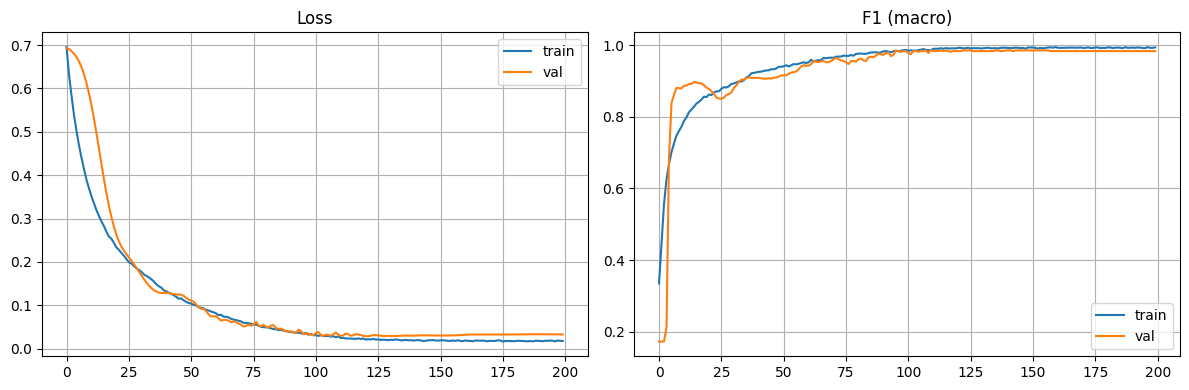

Training complete. Best val F1 = 0.9853 at epoch 108
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9986    0.9813    0.9899       748
           1     0.9355    0.9951    0.9644       204

    accuracy                         0.9842       952
   macro avg     0.9671    0.9882    0.9771       952
weighted avg     0.9851    0.9842    0.9844       952

Overall Accuracy: 0.9842
Macro Precision: 0.9671
Macro Recall:    0.9882
Macro F1:        0.9771
Fold 0: Train users: 40, Val users: 5, Test users: 6
Train windows: 6736, Val windows: 816, Test windows: 952
Class weights: tensor([0.6266, 2.4747])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:29<00:00,  6.84epoch/s, TL=0.007, VL=0.046, VF1=0.993, best VF1=0.993, best Epoch=14]


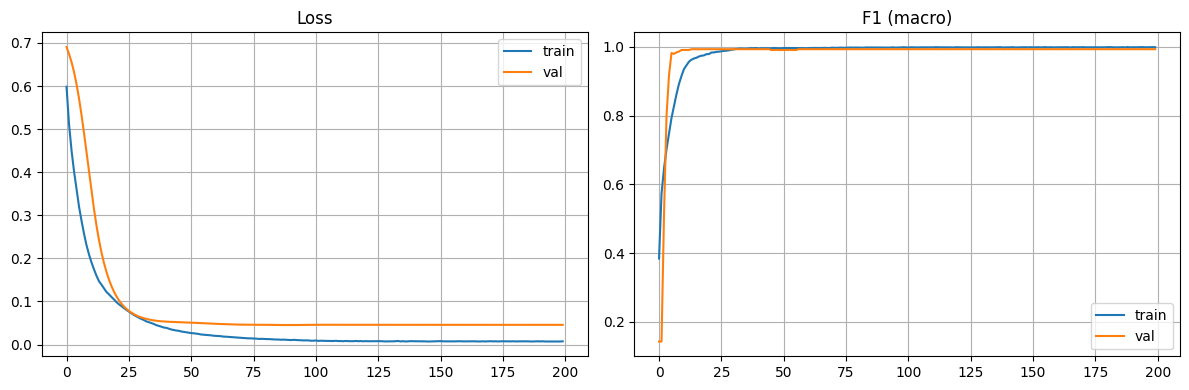

Training complete. Best val F1 = 0.9933 at epoch 14
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       748
           1     1.0000    1.0000    1.0000       204

    accuracy                         1.0000       952
   macro avg     1.0000    1.0000    1.0000       952
weighted avg     1.0000    1.0000    1.0000       952

Overall Accuracy: 1.0000
Macro Precision: 1.0000
Macro Recall:    1.0000
Macro F1:        1.0000
Fold 0: Train users: 40, Val users: 5, Test users: 6
Train windows: 6736, Val windows: 816, Test windows: 952
Class weights: tensor([0.6187, 2.6068])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:30<00:00,  6.57epoch/s, TL=0.031, VL=0.075, VF1=0.983, best VF1=0.983, best Epoch=145]


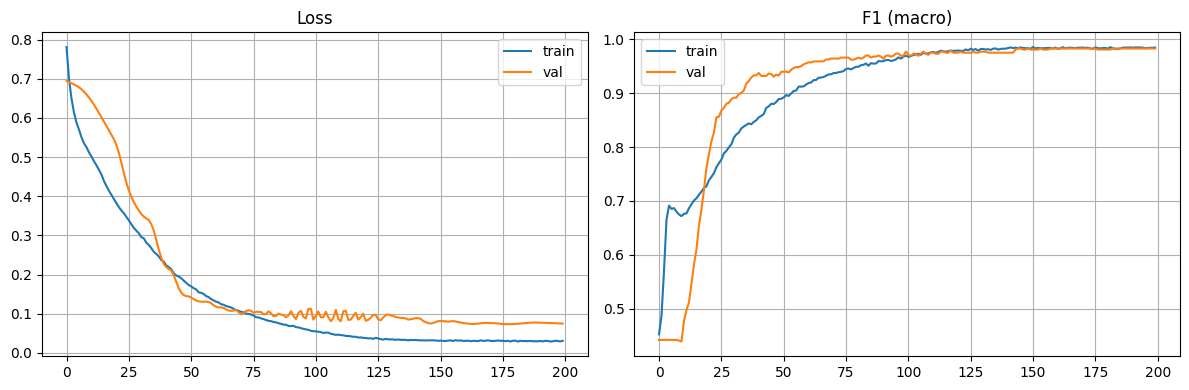

Training complete. Best val F1 = 0.9831 at epoch 145
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9758    0.8760    0.9232       782
           1     0.6120    0.9000    0.7286       170

    accuracy                         0.8803       952
   macro avg     0.7939    0.8880    0.8259       952
weighted avg     0.9108    0.8803    0.8884       952

Overall Accuracy: 0.8803
Macro Precision: 0.7939
Macro Recall:    0.8880
Macro F1:        0.8259
Fold 0: Train users: 40, Val users: 5, Test users: 6
Train windows: 6736, Val windows: 816, Test windows: 952
Class weights: tensor([0.6265, 2.4765])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:30<00:00,  6.51epoch/s, TL=0.064, VL=0.025, VF1=0.984, best VF1=0.985, best Epoch=87]


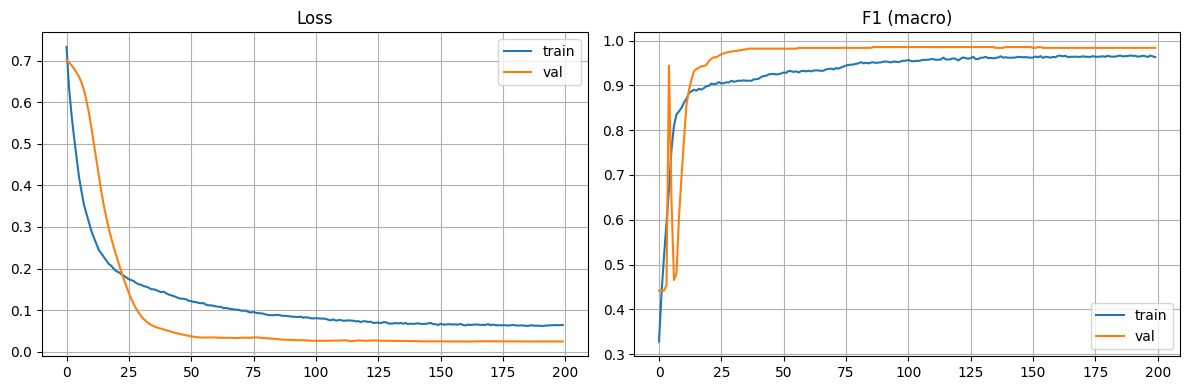

Training complete. Best val F1 = 0.9854 at epoch 87
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9460    0.8436    0.8919       748
           1     0.5895    0.8235    0.6871       204

    accuracy                         0.8393       952
   macro avg     0.7678    0.8336    0.7895       952
weighted avg     0.8696    0.8393    0.8480       952

Overall Accuracy: 0.8393
Macro Precision: 0.7678
Macro Recall:    0.8336
Macro F1:        0.7895
Fold 0: Train users: 40, Val users: 5, Test users: 6
Train windows: 6736, Val windows: 816, Test windows: 952
Class weights: tensor([0.6265, 2.4765])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:29<00:00,  6.84epoch/s, TL=0.081, VL=0.033, VF1=0.991, best VF1=0.996, best Epoch=90]


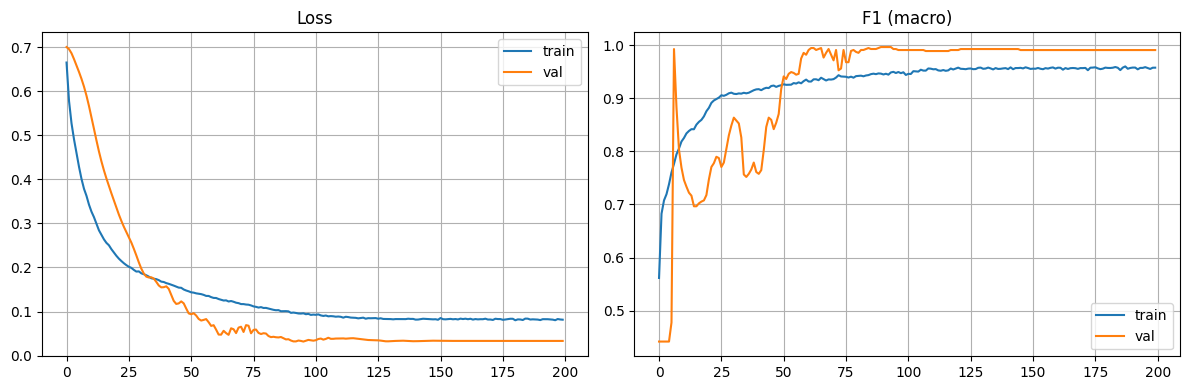

Training complete. Best val F1 = 0.9963 at epoch 90
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9001    0.8990    0.8996       782
           1     0.5380    0.5412    0.5396       170

    accuracy                         0.8351       952
   macro avg     0.7191    0.7201    0.7196       952
weighted avg     0.8355    0.8351    0.8353       952

Overall Accuracy: 0.8351
Macro Precision: 0.7191
Macro Recall:    0.7201
Macro F1:        0.7196
Macro F1: 0.7822






##################################################
Fold: 1
Fold 1: Train users: 41, Val users: 5, Test users: 5
Train windows: 6872, Val windows: 816, Test windows: 816
Class weights: tensor([0.6276, 2.4596])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:31<00:00,  6.39epoch/s, TL=0.038, VL=0.316, VF1=0.902, best VF1=0.927, best Epoch=69]


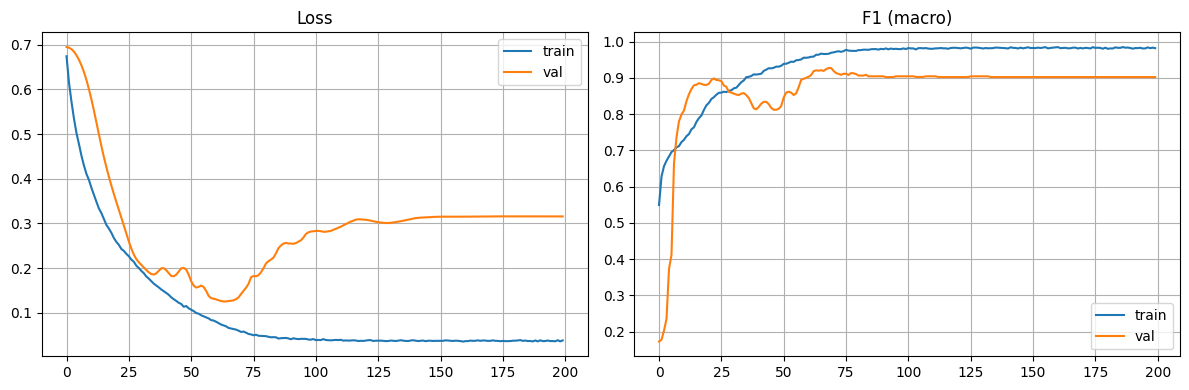

Training complete. Best val F1 = 0.9271 at epoch 69
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9984    0.9814    0.9899       646
           1     0.9337    0.9941    0.9630       170

    accuracy                         0.9841       816
   macro avg     0.9661    0.9878    0.9764       816
weighted avg     0.9849    0.9841    0.9842       816

Overall Accuracy: 0.9841
Macro Precision: 0.9661
Macro Recall:    0.9878
Macro F1:        0.9764
Fold 1: Train users: 41, Val users: 5, Test users: 5
Train windows: 6872, Val windows: 816, Test windows: 816
Class weights: tensor([0.6274, 2.4631])
Total trainable parameters: 4167


Training: 100%|██████| 200/200 [00:31<00:00,  6.36epoch/s, TL=0.012, VL=0.060, VF1=0.941, best VF1=0.994, best Epoch=7]


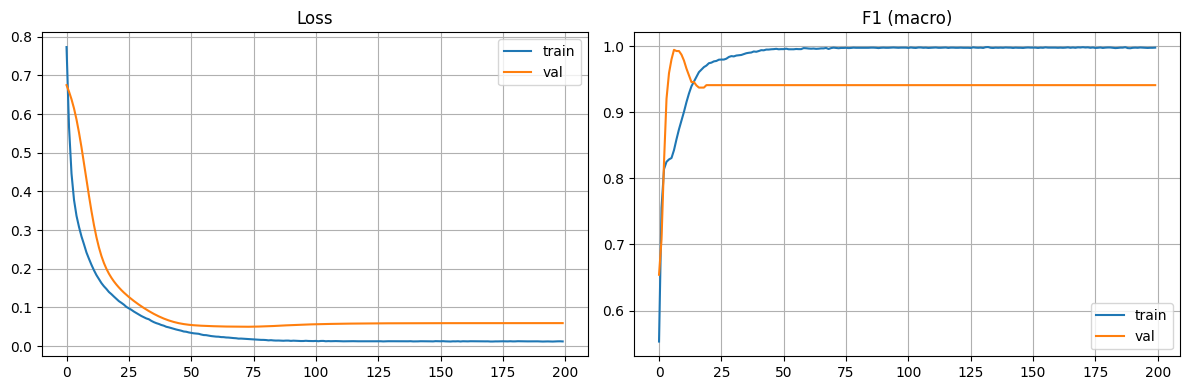

Training complete. Best val F1 = 0.9945 at epoch 7
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9956    1.0000    0.9978       680
           1     1.0000    0.9779    0.9888       136

    accuracy                         0.9963       816
   macro avg     0.9978    0.9890    0.9933       816
weighted avg     0.9963    0.9963    0.9963       816

Overall Accuracy: 0.9963
Macro Precision: 0.9978
Macro Recall:    0.9890
Macro F1:        0.9933
Fold 1: Train users: 41, Val users: 5, Test users: 5
Train windows: 6872, Val windows: 816, Test windows: 816
Class weights: tensor([0.6195, 2.5913])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:31<00:00,  6.34epoch/s, TL=0.067, VL=0.175, VF1=0.887, best VF1=0.916, best Epoch=31]


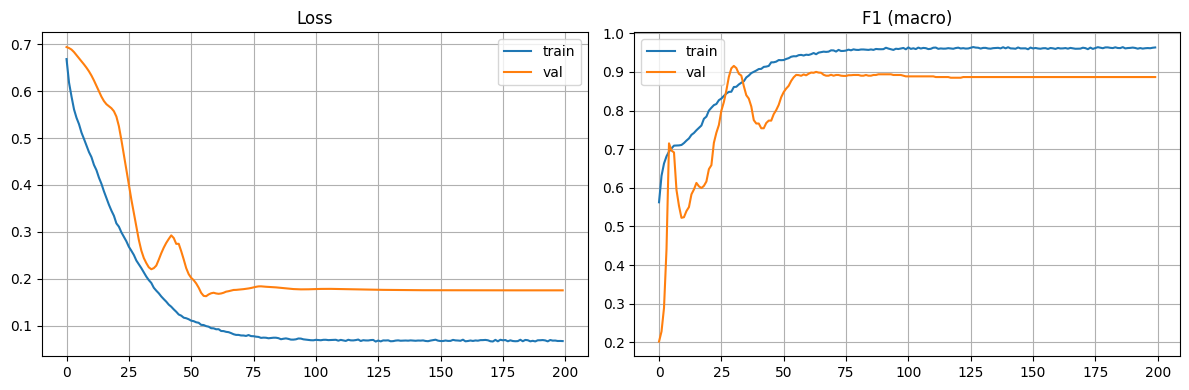

Training complete. Best val F1 = 0.9157 at epoch 31
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9772    0.9938    0.9854       646
           1     0.9748    0.9118    0.9422       170

    accuracy                         0.9767       816
   macro avg     0.9760    0.9528    0.9638       816
weighted avg     0.9767    0.9767    0.9764       816

Overall Accuracy: 0.9767
Macro Precision: 0.9760
Macro Recall:    0.9528
Macro F1:        0.9638
Fold 1: Train users: 41, Val users: 5, Test users: 5
Train windows: 6872, Val windows: 816, Test windows: 816
Class weights: tensor([0.6272, 2.4648])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:31<00:00,  6.44epoch/s, TL=0.115, VL=0.205, VF1=0.845, best VF1=0.872, best Epoch=29]


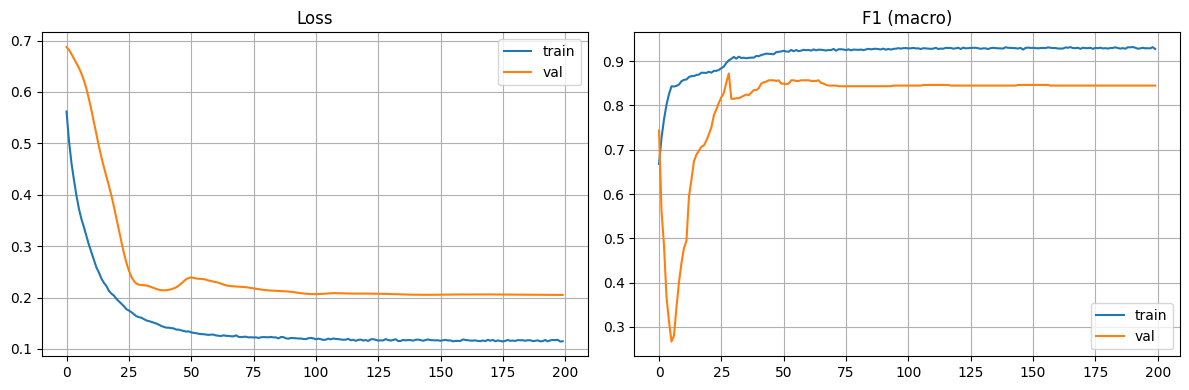

Training complete. Best val F1 = 0.8720 at epoch 29
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9907    0.9953       646
           1     0.9659    1.0000    0.9827       170

    accuracy                         0.9926       816
   macro avg     0.9830    0.9954    0.9890       816
weighted avg     0.9929    0.9926    0.9927       816

Overall Accuracy: 0.9926
Macro Precision: 0.9830
Macro Recall:    0.9954
Macro F1:        0.9890
Fold 1: Train users: 41, Val users: 5, Test users: 5
Train windows: 6872, Val windows: 816, Test windows: 816
Class weights: tensor([0.6234, 2.5265])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:31<00:00,  6.45epoch/s, TL=0.139, VL=0.195, VF1=0.921, best VF1=0.922, best Epoch=56]


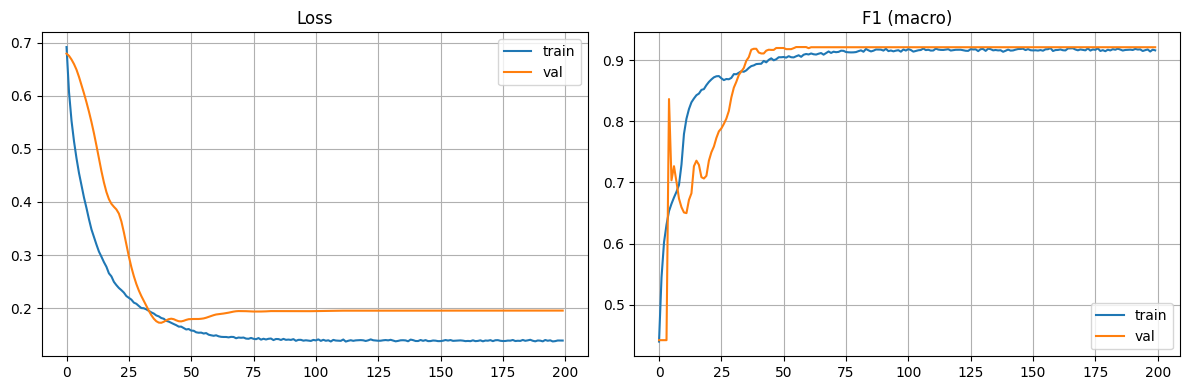

Training complete. Best val F1 = 0.9217 at epoch 56
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9985    0.9992       646
           1     0.9942    1.0000    0.9971       170

    accuracy                         0.9988       816
   macro avg     0.9971    0.9992    0.9981       816
weighted avg     0.9988    0.9988    0.9988       816

Overall Accuracy: 0.9988
Macro Precision: 0.9971
Macro Recall:    0.9992
Macro F1:        0.9981
Macro F1: 0.9830






##################################################
Fold: 2
Fold 2: Train users: 41, Val users: 5, Test users: 5
Train windows: 6872, Val windows: 816, Test windows: 816
Class weights: tensor([0.6276, 2.4596])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:31<00:00,  6.35epoch/s, TL=0.039, VL=0.217, VF1=0.905, best VF1=0.910, best Epoch=129]


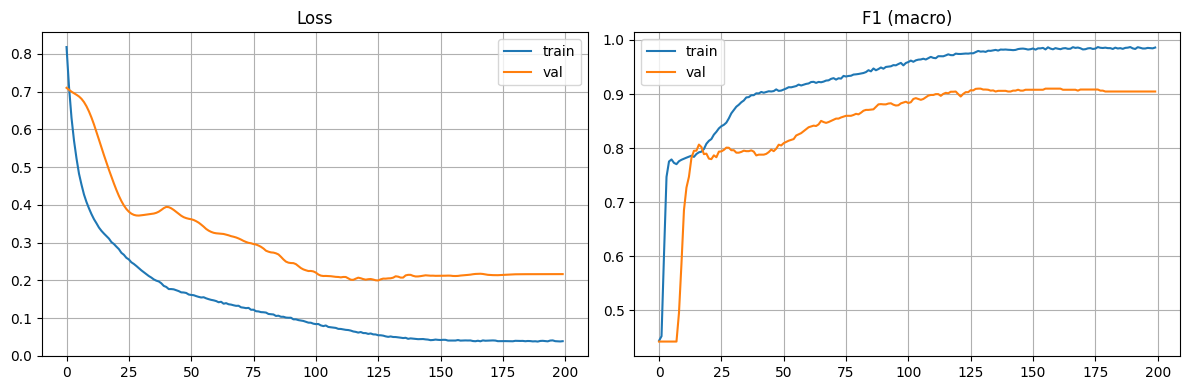

Training complete. Best val F1 = 0.9099 at epoch 129
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9444    0.9721    0.9580       646
           1     0.8808    0.7824    0.8287       170

    accuracy                         0.9326       816
   macro avg     0.9126    0.8772    0.8934       816
weighted avg     0.9311    0.9326    0.9311       816

Overall Accuracy: 0.9326
Macro Precision: 0.9126
Macro Recall:    0.8772
Macro F1:        0.8934
Fold 2: Train users: 41, Val users: 5, Test users: 5
Train windows: 6872, Val windows: 816, Test windows: 816
Class weights: tensor([0.6235, 2.5246])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:31<00:00,  6.31epoch/s, TL=0.008, VL=0.019, VF1=0.991, best VF1=0.994, best Epoch=48]


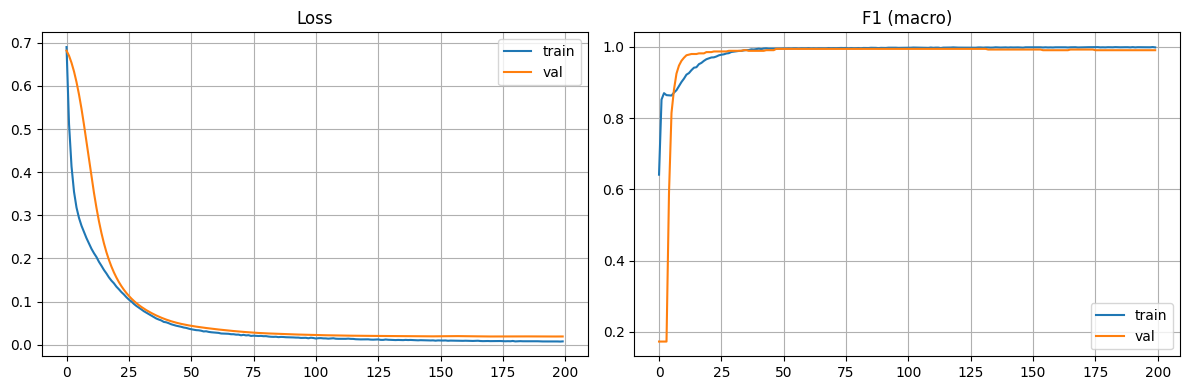

Training complete. Best val F1 = 0.9944 at epoch 48
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9474    0.9730       646
           1     0.8333    1.0000    0.9091       170

    accuracy                         0.9583       816
   macro avg     0.9167    0.9737    0.9410       816
weighted avg     0.9653    0.9583    0.9597       816

Overall Accuracy: 0.9583
Macro Precision: 0.9167
Macro Recall:    0.9737
Macro F1:        0.9410
Fold 2: Train users: 41, Val users: 5, Test users: 5
Train windows: 6872, Val windows: 816, Test windows: 816
Class weights: tensor([0.6234, 2.5265])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:31<00:00,  6.31epoch/s, TL=0.063, VL=0.300, VF1=0.835, best VF1=0.835, best Epoch=132]


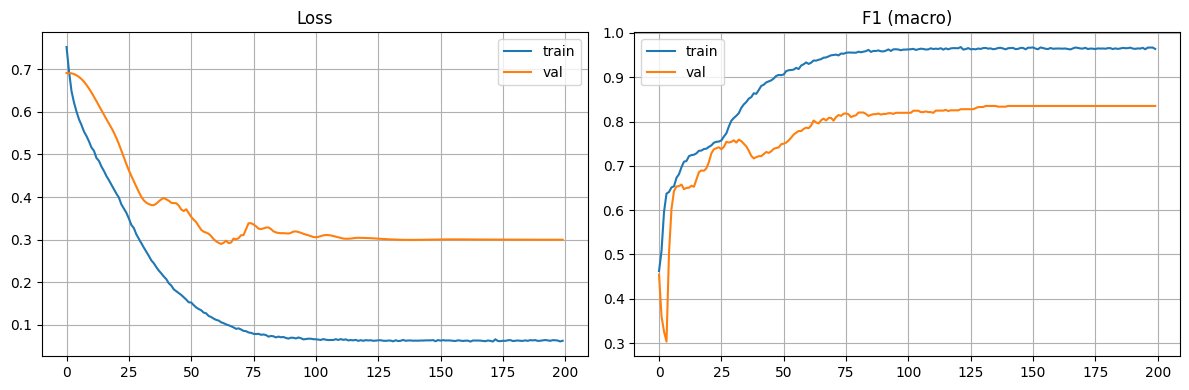

Training complete. Best val F1 = 0.8351 at epoch 132
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9517    0.9279    0.9397       680
           1     0.6797    0.7647    0.7197       136

    accuracy                         0.9007       816
   macro avg     0.8157    0.8463    0.8297       816
weighted avg     0.9064    0.9007    0.9030       816

Overall Accuracy: 0.9007
Macro Precision: 0.8157
Macro Recall:    0.8463
Macro F1:        0.8297
Fold 2: Train users: 41, Val users: 5, Test users: 5
Train windows: 6872, Val windows: 816, Test windows: 816
Class weights: tensor([0.6272, 2.4648])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:31<00:00,  6.30epoch/s, TL=0.098, VL=0.074, VF1=0.931, best VF1=0.948, best Epoch=37]


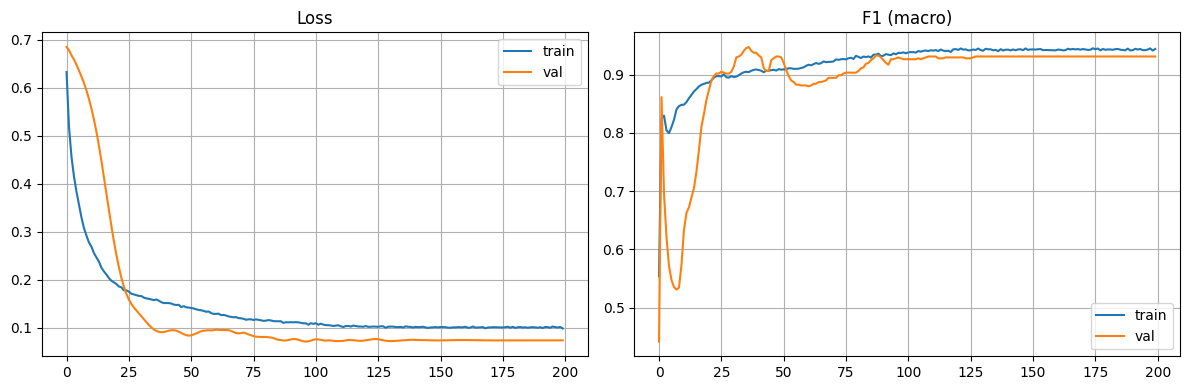

Training complete. Best val F1 = 0.9476 at epoch 37
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9479    0.9582    0.9530       646
           1     0.8344    0.8000    0.8168       170

    accuracy                         0.9252       816
   macro avg     0.8911    0.8791    0.8849       816
weighted avg     0.9243    0.9252    0.9247       816

Overall Accuracy: 0.9252
Macro Precision: 0.8911
Macro Recall:    0.8791
Macro F1:        0.8849
Fold 2: Train users: 41, Val users: 5, Test users: 5
Train windows: 6872, Val windows: 816, Test windows: 816
Class weights: tensor([0.6234, 2.5265])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:31<00:00,  6.36epoch/s, TL=0.100, VL=0.085, VF1=0.966, best VF1=0.972, best Epoch=153]


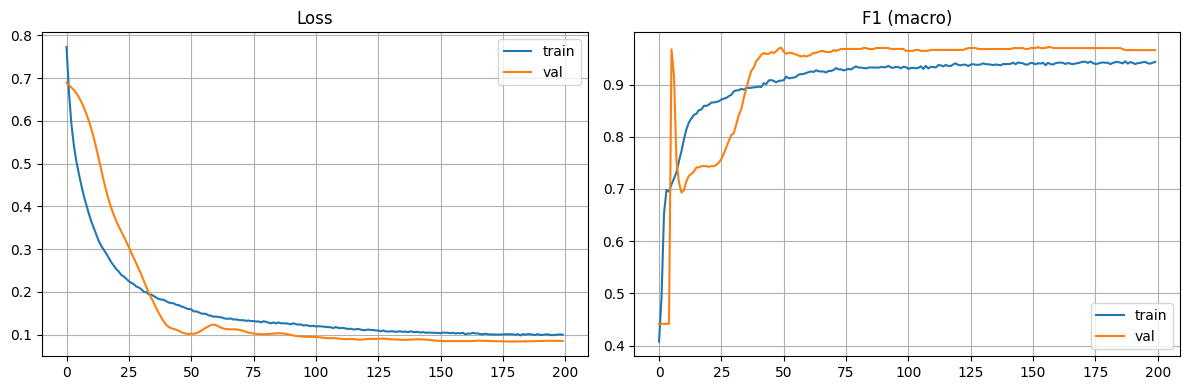

Training complete. Best val F1 = 0.9717 at epoch 153
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9744    0.8854    0.9278       646
           1     0.6769    0.9118    0.7769       170

    accuracy                         0.8909       816
   macro avg     0.8257    0.8986    0.8524       816
weighted avg     0.9124    0.8909    0.8964       816

Overall Accuracy: 0.8909
Macro Precision: 0.8257
Macro Recall:    0.8986
Macro F1:        0.8524
Macro F1: 0.8609






##################################################
Fold: 3
Fold 3: Train users: 41, Val users: 5, Test users: 5
Train windows: 6836, Val windows: 852, Test windows: 816
Class weights: tensor([0.6283, 2.4484])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:31<00:00,  6.25epoch/s, TL=0.078, VL=0.368, VF1=0.789, best VF1=0.789, best Epoch=146]


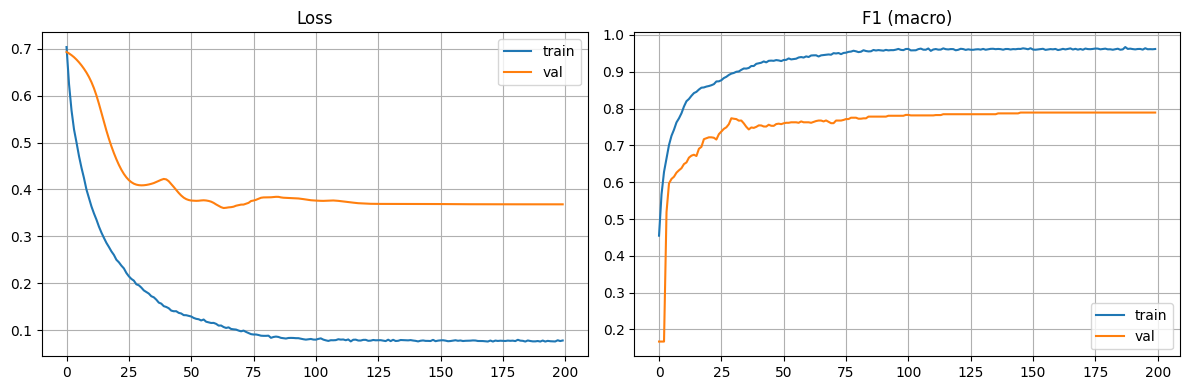

Training complete. Best val F1 = 0.7892 at epoch 146
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9414    0.9706    0.9558       646
           1     0.8733    0.7706    0.8187       170

    accuracy                         0.9289       816
   macro avg     0.9074    0.8706    0.8873       816
weighted avg     0.9273    0.9289    0.9272       816

Overall Accuracy: 0.9289
Macro Precision: 0.9074
Macro Recall:    0.8706
Macro F1:        0.8873
Fold 3: Train users: 41, Val users: 5, Test users: 5
Train windows: 6836, Val windows: 852, Test windows: 816
Class weights: tensor([0.6242, 2.5132])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:31<00:00,  6.33epoch/s, TL=0.007, VL=0.040, VF1=0.995, best VF1=0.996, best Epoch=148]


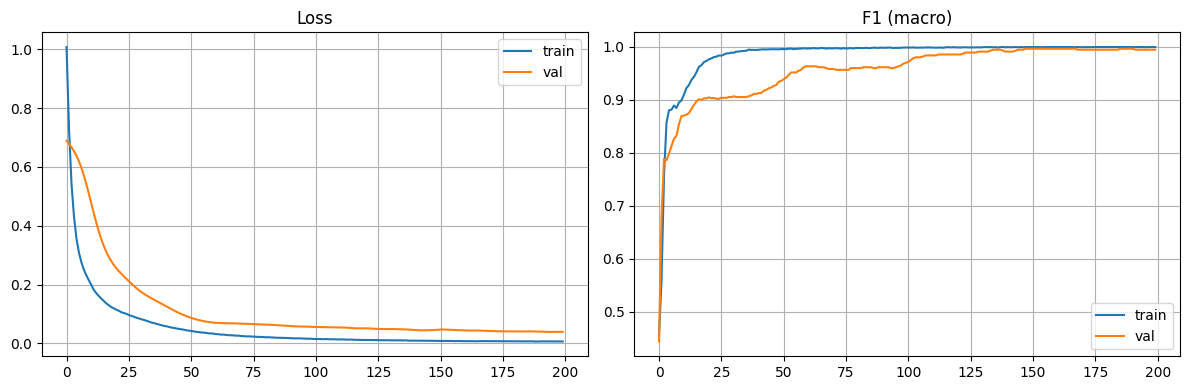

Training complete. Best val F1 = 0.9963 at epoch 148
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9954    0.9954    0.9954       646
           1     0.9824    0.9824    0.9824       170

    accuracy                         0.9926       816
   macro avg     0.9889    0.9889    0.9889       816
weighted avg     0.9926    0.9926    0.9926       816

Overall Accuracy: 0.9926
Macro Precision: 0.9889
Macro Recall:    0.9889
Macro F1:        0.9889
Fold 3: Train users: 41, Val users: 5, Test users: 5
Train windows: 6836, Val windows: 852, Test windows: 816
Class weights: tensor([0.6203, 2.5777])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:31<00:00,  6.35epoch/s, TL=0.081, VL=0.333, VF1=0.817, best VF1=0.847, best Epoch=34]


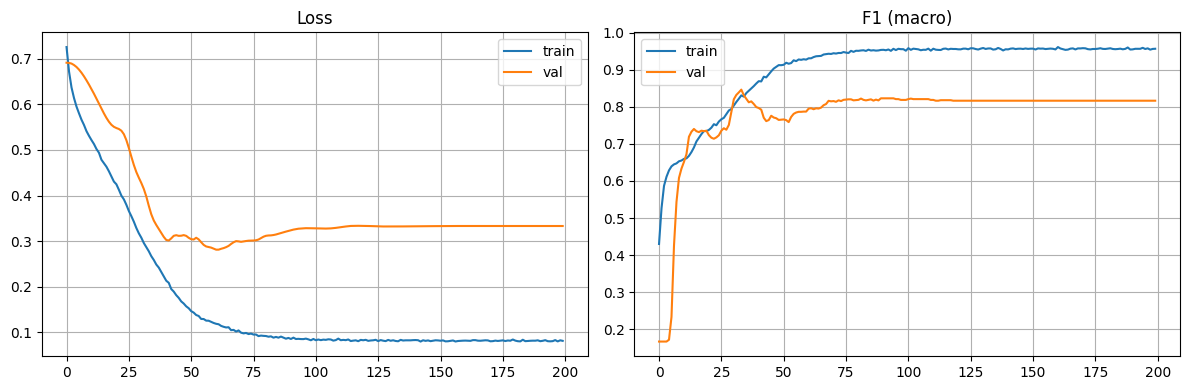

Training complete. Best val F1 = 0.8467 at epoch 34
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9883    0.8691    0.9249       680
           1     0.5917    0.9485    0.7288       136

    accuracy                         0.8824       816
   macro avg     0.7900    0.9088    0.8268       816
weighted avg     0.9222    0.8824    0.8922       816

Overall Accuracy: 0.8824
Macro Precision: 0.7900
Macro Recall:    0.9088
Macro F1:        0.8268
Fold 3: Train users: 41, Val users: 5, Test users: 5
Train windows: 6836, Val windows: 852, Test windows: 816
Class weights: tensor([0.6281, 2.4519])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:30<00:00,  6.58epoch/s, TL=0.089, VL=0.222, VF1=0.904, best VF1=0.904, best Epoch=131]


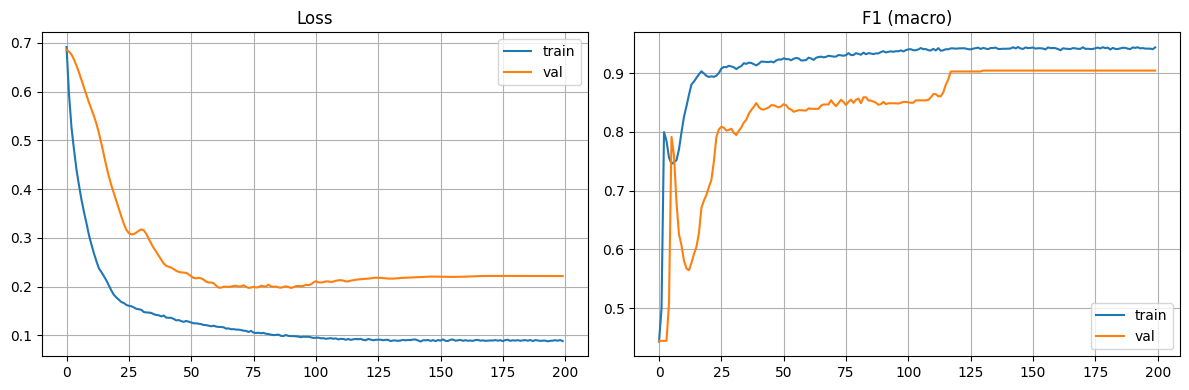

Training complete. Best val F1 = 0.9041 at epoch 131
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9952    0.9644    0.9796       646
           1     0.8789    0.9824    0.9278       170

    accuracy                         0.9681       816
   macro avg     0.9371    0.9734    0.9537       816
weighted avg     0.9710    0.9681    0.9688       816

Overall Accuracy: 0.9681
Macro Precision: 0.9371
Macro Recall:    0.9734
Macro F1:        0.9537
Fold 3: Train users: 41, Val users: 5, Test users: 5
Train windows: 6836, Val windows: 852, Test windows: 816
Class weights: tensor([0.6242, 2.5132])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:31<00:00,  6.35epoch/s, TL=0.093, VL=0.193, VF1=0.915, best VF1=0.922, best Epoch=100]


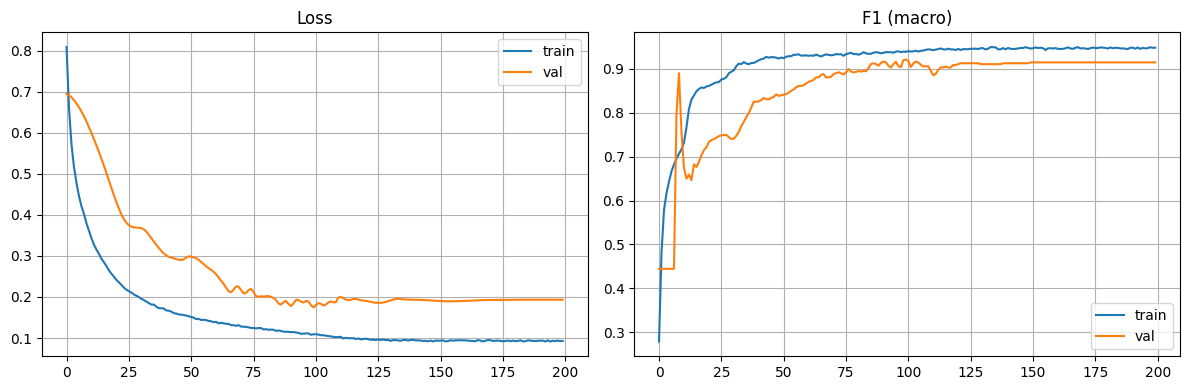

Training complete. Best val F1 = 0.9215 at epoch 100
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9830    0.9845    0.9838       646
           1     0.9408    0.9353    0.9381       170

    accuracy                         0.9743       816
   macro avg     0.9619    0.9599    0.9609       816
weighted avg     0.9742    0.9743    0.9742       816

Overall Accuracy: 0.9743
Macro Precision: 0.9619
Macro Recall:    0.9599
Macro F1:        0.9609
Macro F1: 0.9077






##################################################
Fold: 4
Fold 4: Train users: 41, Val users: 5, Test users: 5
Train windows: 6801, Val windows: 851, Test windows: 852
Class weights: tensor([0.6290, 2.4376])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:31<00:00,  6.43epoch/s, TL=0.059, VL=0.282, VF1=0.889, best VF1=0.891, best Epoch=169]


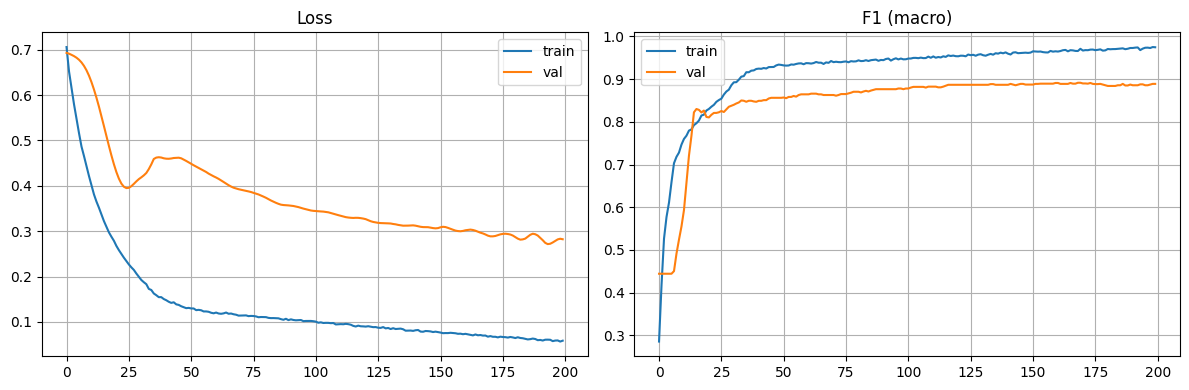

Training complete. Best val F1 = 0.8915 at epoch 169
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9517    0.9266    0.9390       681
           1     0.7354    0.8129    0.7722       171

    accuracy                         0.9038       852
   macro avg     0.8436    0.8697    0.8556       852
weighted avg     0.9083    0.9038    0.9055       852

Overall Accuracy: 0.9038
Macro Precision: 0.8436
Macro Recall:    0.8697
Macro F1:        0.8556
Fold 4: Train users: 41, Val users: 5, Test users: 5
Train windows: 6801, Val windows: 851, Test windows: 852
Class weights: tensor([0.6250, 2.5004])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:30<00:00,  6.63epoch/s, TL=0.006, VL=0.028, VF1=0.989, best VF1=0.991, best Epoch=36]


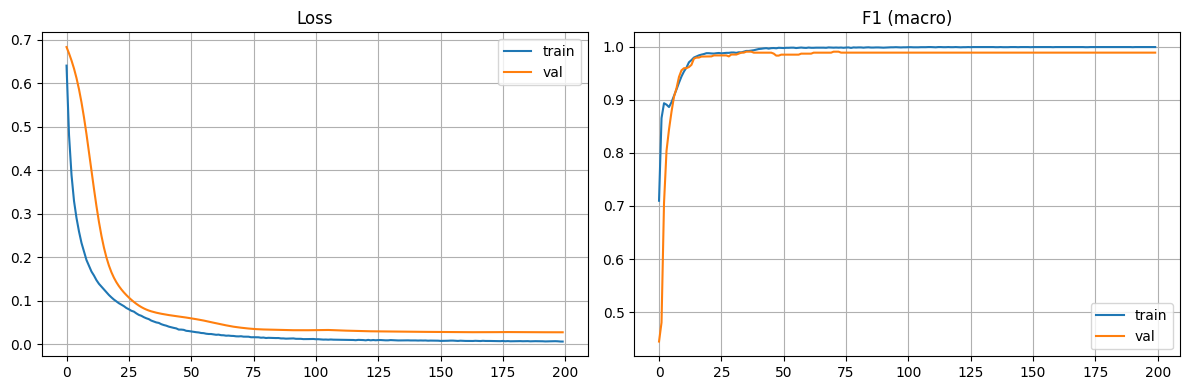

Training complete. Best val F1 = 0.9908 at epoch 36
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9971    0.9985       681
           1     0.9884    1.0000    0.9942       171

    accuracy                         0.9977       852
   macro avg     0.9942    0.9985    0.9964       852
weighted avg     0.9977    0.9977    0.9977       852

Overall Accuracy: 0.9977
Macro Precision: 0.9942
Macro Recall:    0.9985
Macro F1:        0.9964
Fold 4: Train users: 41, Val users: 5, Test users: 5
Train windows: 6801, Val windows: 851, Test windows: 852
Class weights: tensor([0.6173, 2.6320])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:29<00:00,  6.71epoch/s, TL=0.039, VL=0.346, VF1=0.789, best VF1=0.810, best Epoch=116]


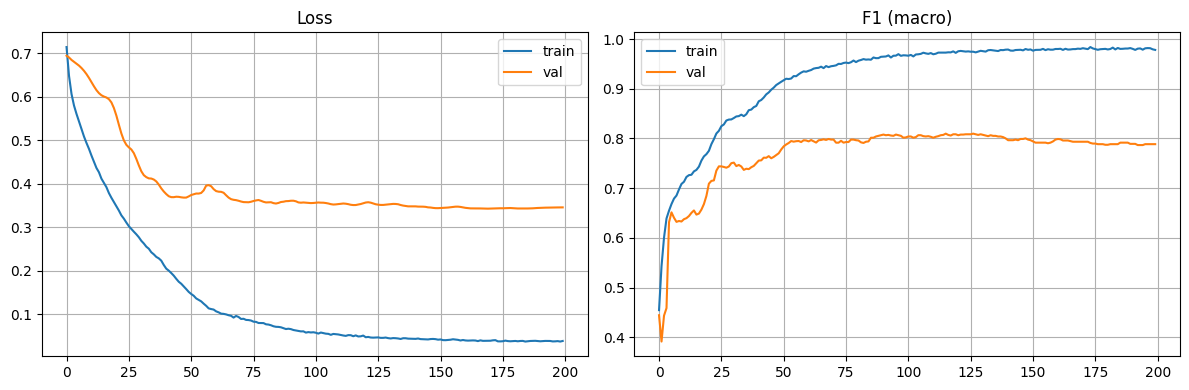

Training complete. Best val F1 = 0.8097 at epoch 116
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9610    0.9032    0.9312       682
           1     0.6872    0.8529    0.7612       170

    accuracy                         0.8932       852
   macro avg     0.8241    0.8781    0.8462       852
weighted avg     0.9064    0.8932    0.8973       852

Overall Accuracy: 0.8932
Macro Precision: 0.8241
Macro Recall:    0.8781
Macro F1:        0.8462
Fold 4: Train users: 41, Val users: 5, Test users: 5
Train windows: 6801, Val windows: 851, Test windows: 852
Class weights: tensor([0.6289, 2.4394])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:30<00:00,  6.59epoch/s, TL=0.100, VL=0.418, VF1=0.873, best VF1=0.901, best Epoch=31]


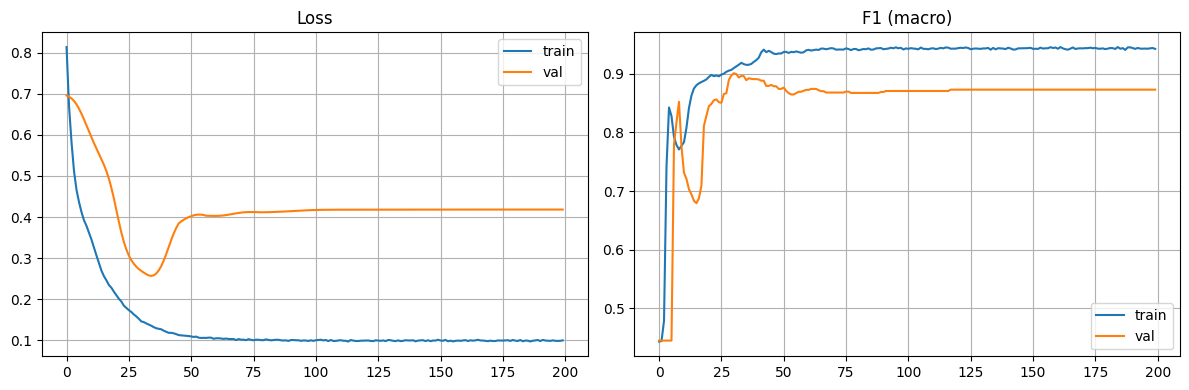

Training complete. Best val F1 = 0.9012 at epoch 31
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9787    0.9428    0.9604       682
           1     0.8000    0.9176    0.8548       170

    accuracy                         0.9378       852
   macro avg     0.8893    0.9302    0.9076       852
weighted avg     0.9430    0.9378    0.9393       852

Overall Accuracy: 0.9378
Macro Precision: 0.8893
Macro Recall:    0.9302
Macro F1:        0.9076
Fold 4: Train users: 41, Val users: 5, Test users: 5
Train windows: 6801, Val windows: 851, Test windows: 852
Class weights: tensor([0.6250, 2.5004])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:28<00:00,  6.94epoch/s, TL=0.084, VL=0.206, VF1=0.889, best VF1=0.891, best Epoch=142]


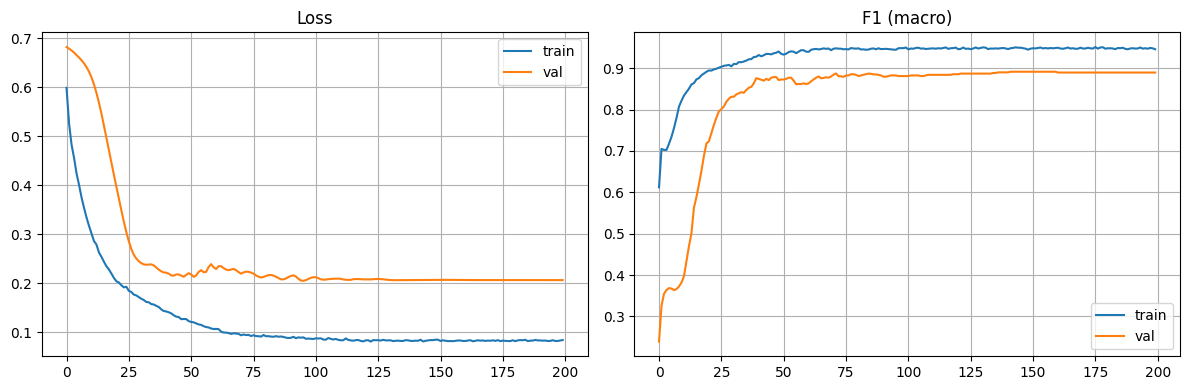

Training complete. Best val F1 = 0.8914 at epoch 142
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9674    0.9150    0.9405       682
           1     0.7198    0.8765    0.7905       170

    accuracy                         0.9073       852
   macro avg     0.8436    0.8957    0.8655       852
weighted avg     0.9180    0.9073    0.9105       852

Overall Accuracy: 0.9073
Macro Precision: 0.8436
Macro Recall:    0.8957
Macro F1:        0.8655
Macro F1: 0.8358






##################################################
Fold: 5
Fold 5: Train users: 41, Val users: 5, Test users: 5
Train windows: 6802, Val windows: 851, Test windows: 851
Class weights: tensor([0.6290, 2.4380])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:29<00:00,  6.72epoch/s, TL=0.010, VL=0.066, VF1=0.964, best VF1=0.966, best Epoch=171]


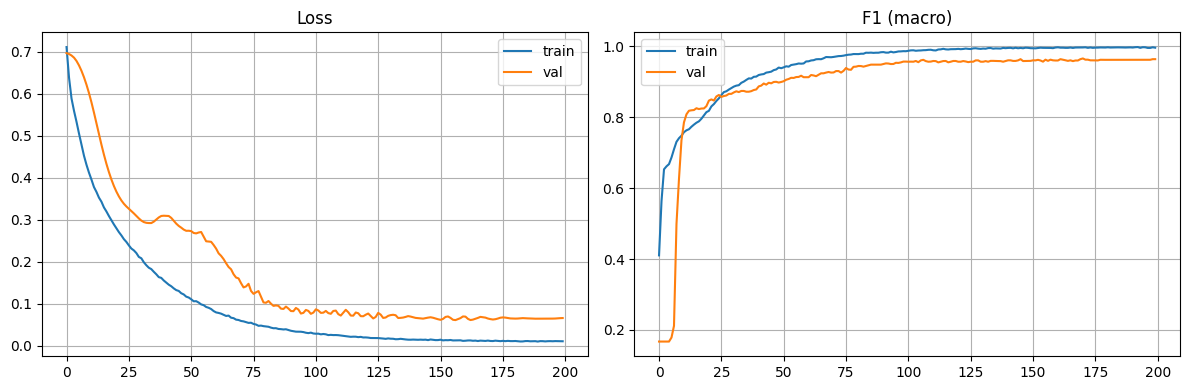

Training complete. Best val F1 = 0.9660 at epoch 171
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9579    0.9706    0.9642       680
           1     0.8765    0.8304    0.8529       171

    accuracy                         0.9424       851
   macro avg     0.9172    0.9005    0.9085       851
weighted avg     0.9416    0.9424    0.9418       851

Overall Accuracy: 0.9424
Macro Precision: 0.9172
Macro Recall:    0.9005
Macro F1:        0.9085
Fold 5: Train users: 41, Val users: 5, Test users: 5
Train windows: 6802, Val windows: 851, Test windows: 851
Class weights: tensor([0.6251, 2.4989])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:30<00:00,  6.48epoch/s, TL=0.006, VL=0.004, VF1=0.998, best VF1=0.998, best Epoch=87]


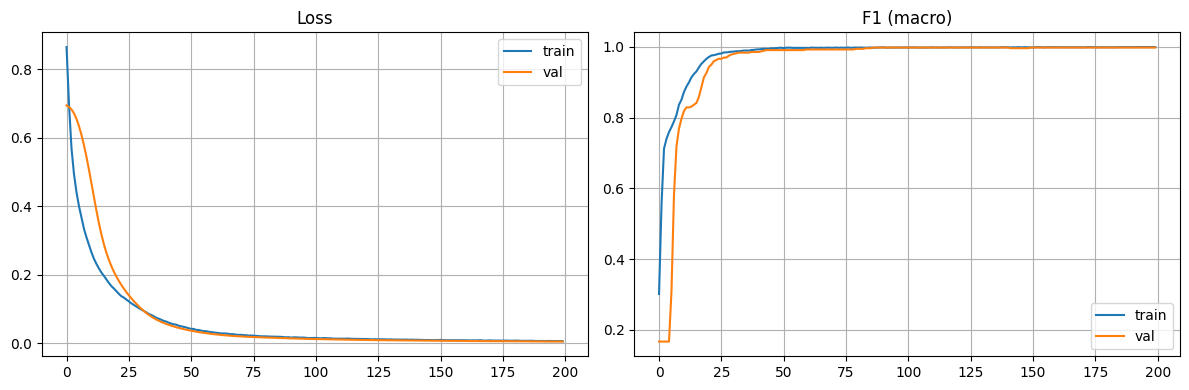

Training complete. Best val F1 = 0.9982 at epoch 87
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9855    1.0000    0.9927       681
           1     1.0000    0.9412    0.9697       170

    accuracy                         0.9882       851
   macro avg     0.9928    0.9706    0.9812       851
weighted avg     0.9884    0.9882    0.9881       851

Overall Accuracy: 0.9882
Macro Precision: 0.9928
Macro Recall:    0.9706
Macro F1:        0.9812
Fold 5: Train users: 41, Val users: 5, Test users: 5
Train windows: 6802, Val windows: 851, Test windows: 851
Class weights: tensor([0.6172, 2.6324])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:29<00:00,  6.74epoch/s, TL=0.035, VL=0.131, VF1=0.929, best VF1=0.941, best Epoch=108]


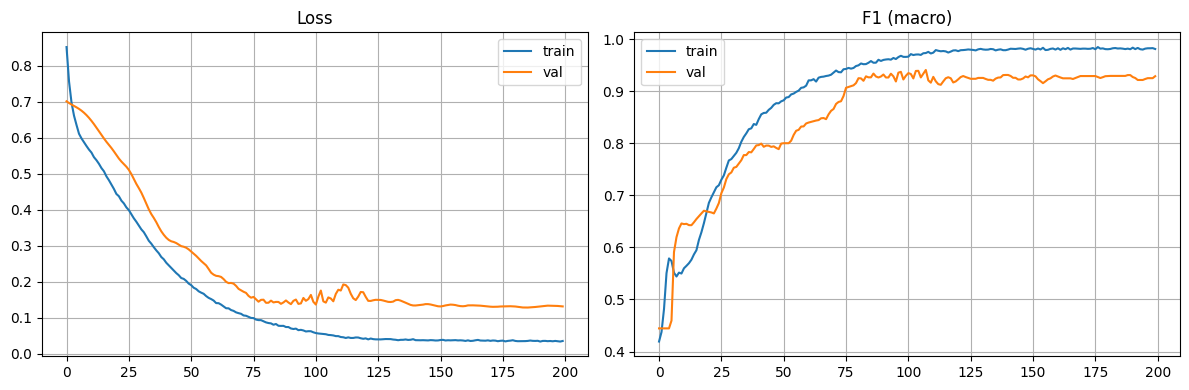

Training complete. Best val F1 = 0.9408 at epoch 108
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9479    0.8811    0.9132       681
           1     0.6284    0.8059    0.7062       170

    accuracy                         0.8660       851
   macro avg     0.7882    0.8435    0.8097       851
weighted avg     0.8841    0.8660    0.8719       851

Overall Accuracy: 0.8660
Macro Precision: 0.7882
Macro Recall:    0.8435
Macro F1:        0.8097
Fold 5: Train users: 41, Val users: 5, Test users: 5
Train windows: 6802, Val windows: 851, Test windows: 851
Class weights: tensor([0.6289, 2.4397])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:30<00:00,  6.59epoch/s, TL=0.069, VL=0.139, VF1=0.953, best VF1=0.953, best Epoch=141]


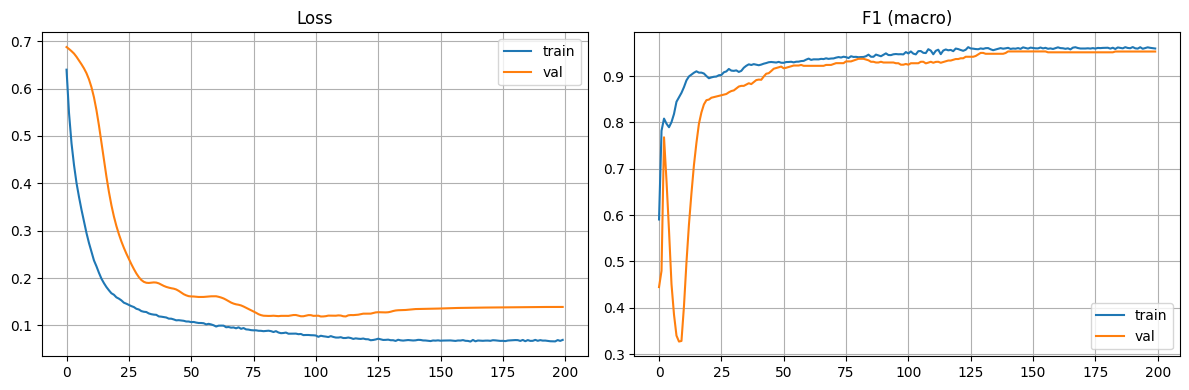

Training complete. Best val F1 = 0.9532 at epoch 141
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9012    0.9780    0.9380       681
           1     0.8661    0.5706    0.6879       170

    accuracy                         0.8966       851
   macro avg     0.8836    0.7743    0.8130       851
weighted avg     0.8942    0.8966    0.8881       851

Overall Accuracy: 0.8966
Macro Precision: 0.8836
Macro Recall:    0.7743
Macro F1:        0.8130
Fold 5: Train users: 41, Val users: 5, Test users: 5
Train windows: 6802, Val windows: 851, Test windows: 851
Class weights: tensor([0.6250, 2.5007])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:30<00:00,  6.51epoch/s, TL=0.099, VL=0.198, VF1=0.876, best VF1=0.896, best Epoch=81]


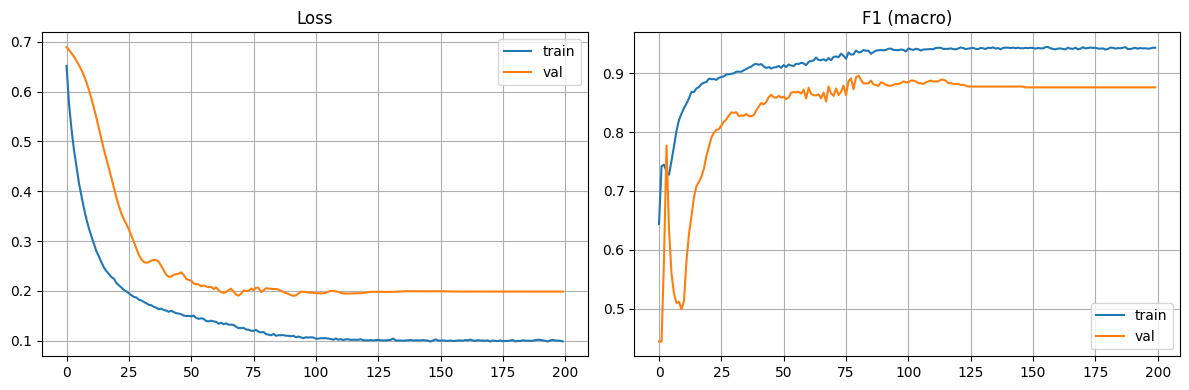

Training complete. Best val F1 = 0.8958 at epoch 81
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9797    0.9207    0.9493       681
           1     0.7441    0.9235    0.8241       170

    accuracy                         0.9213       851
   macro avg     0.8619    0.9221    0.8867       851
weighted avg     0.9326    0.9213    0.9243       851

Overall Accuracy: 0.9213
Macro Precision: 0.8619
Macro Recall:    0.9221
Macro F1:        0.8867
Macro F1: 0.8380






##################################################
Fold: 6
Fold 6: Train users: 41, Val users: 5, Test users: 5
Train windows: 6803, Val windows: 850, Test windows: 851
Class weights: tensor([0.6291, 2.4366])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:27<00:00,  7.20epoch/s, TL=0.023, VL=0.146, VF1=0.912, best VF1=0.923, best Epoch=100]


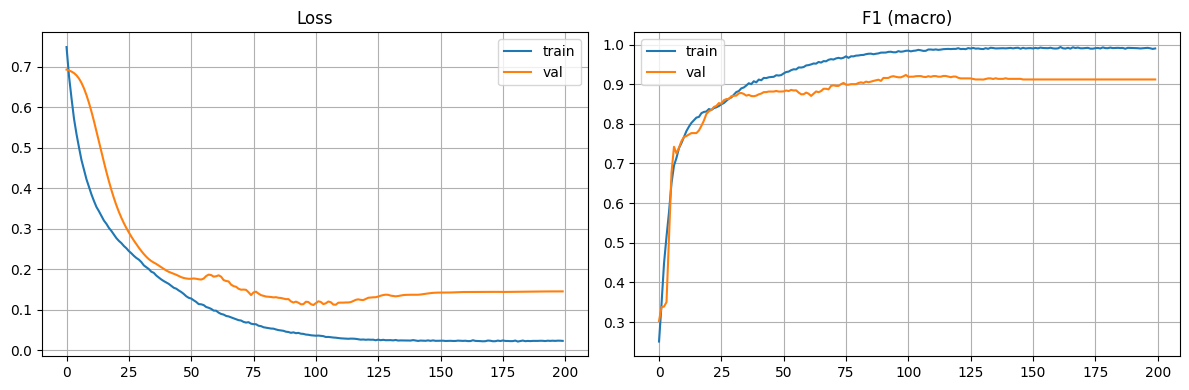

Training complete. Best val F1 = 0.9233 at epoch 100
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9777    0.9676    0.9727       680
           1     0.8764    0.9123    0.8940       171

    accuracy                         0.9565       851
   macro avg     0.9271    0.9400    0.9333       851
weighted avg     0.9574    0.9565    0.9568       851

Overall Accuracy: 0.9565
Macro Precision: 0.9271
Macro Recall:    0.9400
Macro F1:        0.9333
Fold 6: Train users: 41, Val users: 5, Test users: 5
Train windows: 6803, Val windows: 850, Test windows: 851
Class weights: tensor([0.6250, 2.4993])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:30<00:00,  6.56epoch/s, TL=0.007, VL=0.004, VF1=0.998, best VF1=1.000, best Epoch=53]


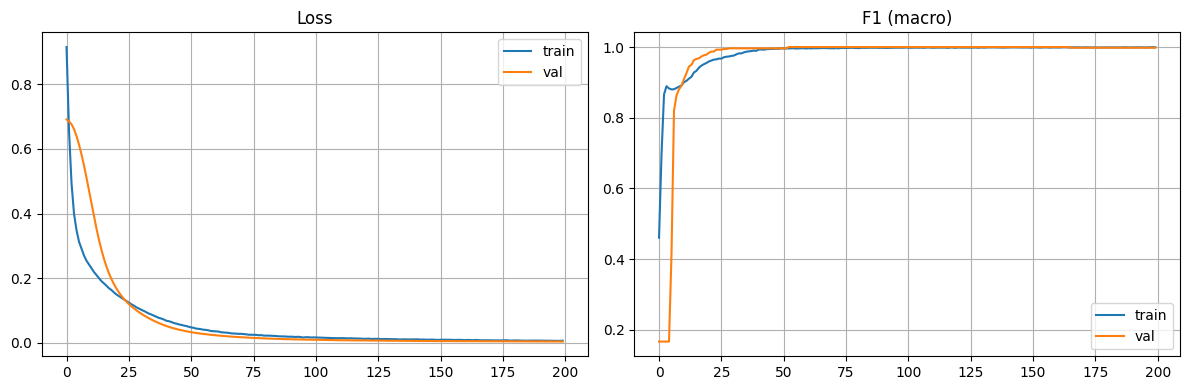

Training complete. Best val F1 = 1.0000 at epoch 53
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9985    0.9971    0.9978       681
           1     0.9883    0.9941    0.9912       170

    accuracy                         0.9965       851
   macro avg     0.9934    0.9956    0.9945       851
weighted avg     0.9965    0.9965    0.9965       851

Overall Accuracy: 0.9965
Macro Precision: 0.9934
Macro Recall:    0.9956
Macro F1:        0.9945
Fold 6: Train users: 41, Val users: 5, Test users: 5
Train windows: 6803, Val windows: 850, Test windows: 851
Class weights: tensor([0.6172, 2.6327])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:30<00:00,  6.59epoch/s, TL=0.033, VL=0.110, VF1=0.952, best VF1=0.963, best Epoch=52]


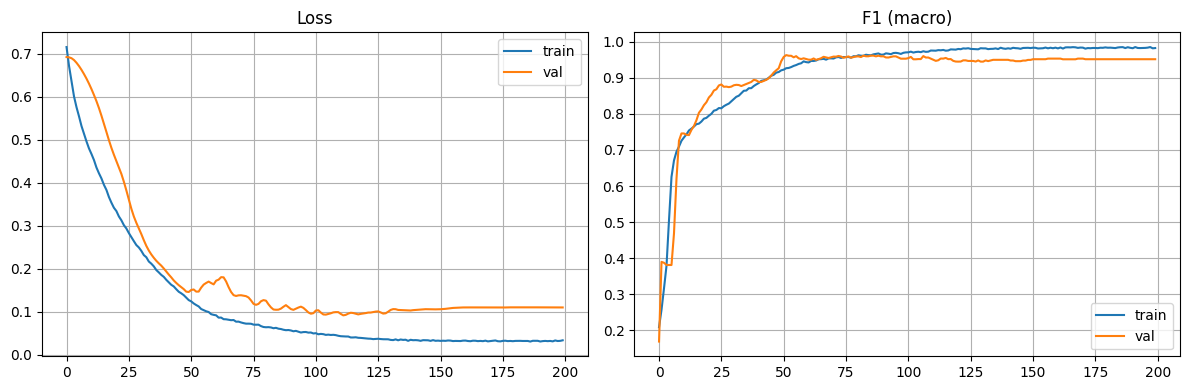

Training complete. Best val F1 = 0.9634 at epoch 52
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9791    0.9633    0.9711       681
           1     0.8619    0.9176    0.8889       170

    accuracy                         0.9542       851
   macro avg     0.9205    0.9405    0.9300       851
weighted avg     0.9557    0.9542    0.9547       851

Overall Accuracy: 0.9542
Macro Precision: 0.9205
Macro Recall:    0.9405
Macro F1:        0.9300
Fold 6: Train users: 41, Val users: 5, Test users: 5
Train windows: 6803, Val windows: 850, Test windows: 851
Class weights: tensor([0.6289, 2.4401])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:30<00:00,  6.52epoch/s, TL=0.134, VL=0.124, VF1=0.927, best VF1=0.927, best Epoch=86]


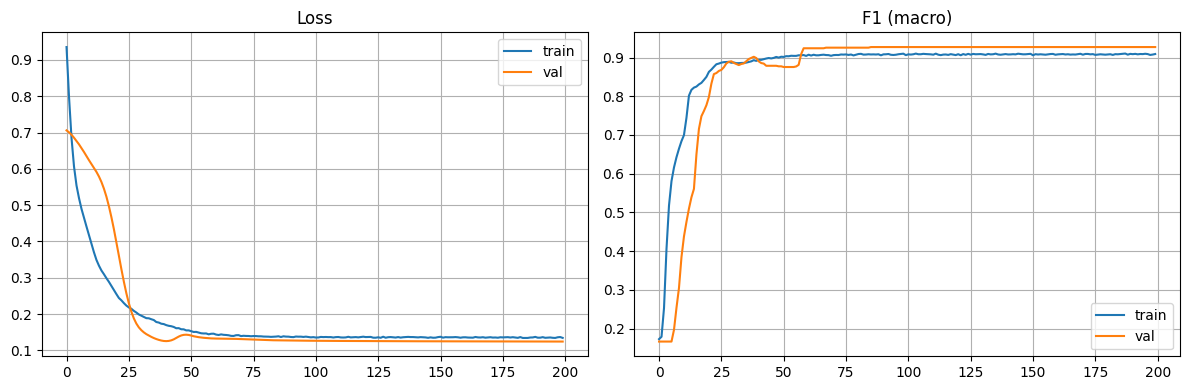

Training complete. Best val F1 = 0.9270 at epoch 86
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9936    0.9163    0.9534       681
           1     0.7444    0.9765    0.8448       170

    accuracy                         0.9283       851
   macro avg     0.8690    0.9464    0.8991       851
weighted avg     0.9438    0.9283    0.9317       851

Overall Accuracy: 0.9283
Macro Precision: 0.8690
Macro Recall:    0.9464
Macro F1:        0.8991
Fold 6: Train users: 41, Val users: 5, Test users: 5
Train windows: 6803, Val windows: 850, Test windows: 851
Class weights: tensor([0.6249, 2.5011])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:30<00:00,  6.47epoch/s, TL=0.075, VL=0.089, VF1=0.959, best VF1=0.959, best Epoch=187]


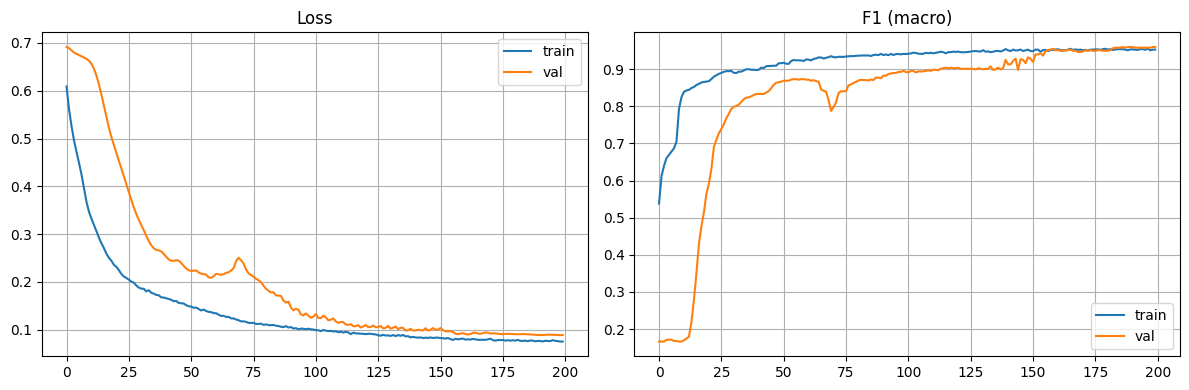

Training complete. Best val F1 = 0.9591 at epoch 187
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9903    0.8972    0.9414       681
           1     0.7009    0.9647    0.8119       170

    accuracy                         0.9107       851
   macro avg     0.8456    0.9310    0.8767       851
weighted avg     0.9325    0.9107    0.9156       851

Overall Accuracy: 0.9107
Macro Precision: 0.8456
Macro Recall:    0.9310
Macro F1:        0.8767
Macro F1: 0.9081






##################################################
Fold: 7
Fold 7: Train users: 41, Val users: 5, Test users: 5
Train windows: 6804, Val windows: 850, Test windows: 850
Class weights: tensor([0.6292, 2.4352])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:30<00:00,  6.58epoch/s, TL=0.082, VL=0.187, VF1=0.935, best VF1=0.941, best Epoch=103]


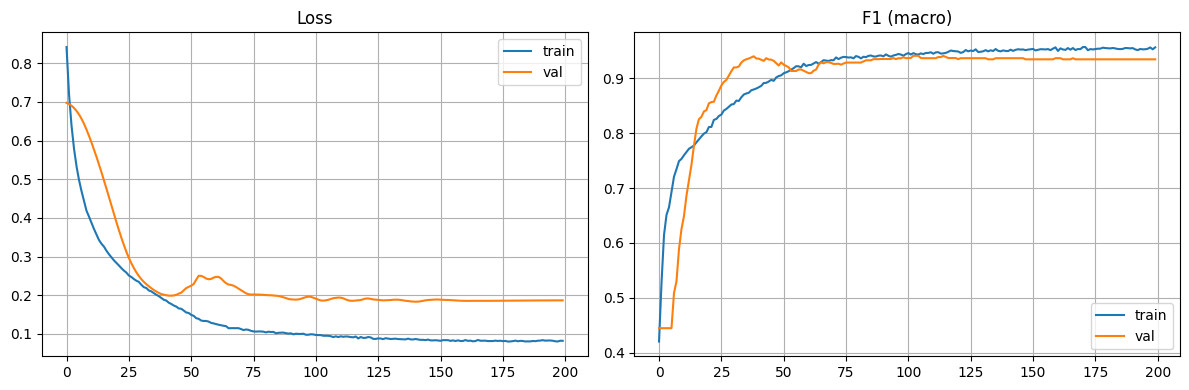

Training complete. Best val F1 = 0.9413 at epoch 103
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9921    0.9279    0.9590       680
           1     0.7710    0.9706    0.8594       170

    accuracy                         0.9365       850
   macro avg     0.8816    0.9493    0.9092       850
weighted avg     0.9479    0.9365    0.9390       850

Overall Accuracy: 0.9365
Macro Precision: 0.8816
Macro Recall:    0.9493
Macro F1:        0.9092
Fold 7: Train users: 41, Val users: 5, Test users: 5
Train windows: 6804, Val windows: 850, Test windows: 850
Class weights: tensor([0.6250, 2.4996])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:31<00:00,  6.39epoch/s, TL=0.008, VL=0.049, VF1=0.985, best VF1=0.987, best Epoch=82]


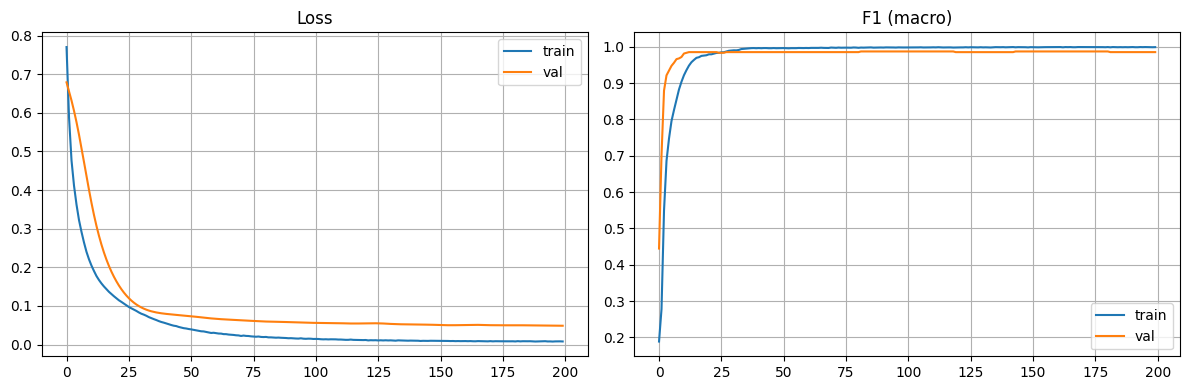

Training complete. Best val F1 = 0.9870 at epoch 82
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9985    0.9993       680
           1     0.9942    1.0000    0.9971       170

    accuracy                         0.9988       850
   macro avg     0.9971    0.9993    0.9982       850
weighted avg     0.9988    0.9988    0.9988       850

Overall Accuracy: 0.9988
Macro Precision: 0.9971
Macro Recall:    0.9993
Macro F1:        0.9982
Fold 7: Train users: 41, Val users: 5, Test users: 5
Train windows: 6804, Val windows: 850, Test windows: 850
Class weights: tensor([0.6172, 2.6331])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:31<00:00,  6.38epoch/s, TL=0.039, VL=0.161, VF1=0.931, best VF1=0.933, best Epoch=188]


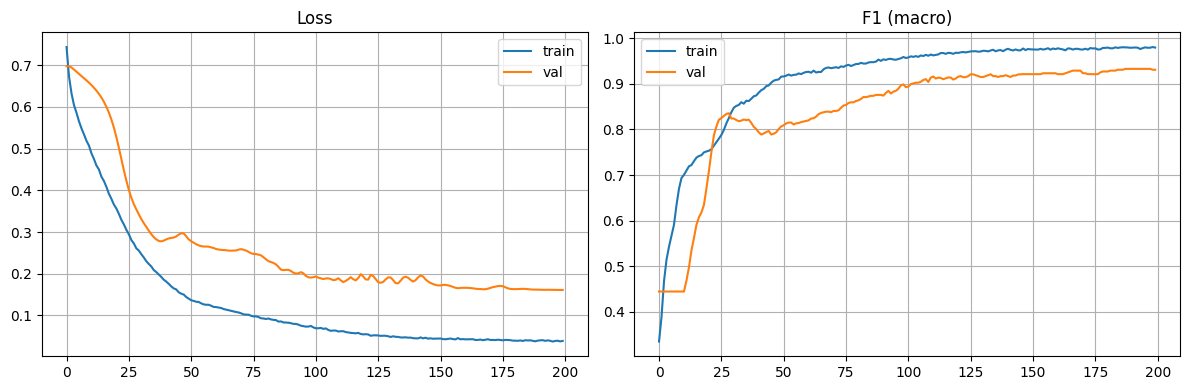

Training complete. Best val F1 = 0.9328 at epoch 188
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9897    0.9868    0.9882       680
           1     0.9477    0.9588    0.9532       170

    accuracy                         0.9812       850
   macro avg     0.9687    0.9728    0.9707       850
weighted avg     0.9813    0.9812    0.9812       850

Overall Accuracy: 0.9812
Macro Precision: 0.9687
Macro Recall:    0.9728
Macro F1:        0.9707
Fold 7: Train users: 41, Val users: 5, Test users: 5
Train windows: 6804, Val windows: 850, Test windows: 850
Class weights: tensor([0.6288, 2.4405])
Total trainable parameters: 4167


Training: 100%|██████| 200/200 [00:31<00:00,  6.26epoch/s, TL=0.093, VL=0.292, VF1=0.885, best VF1=0.910, best Epoch=6]


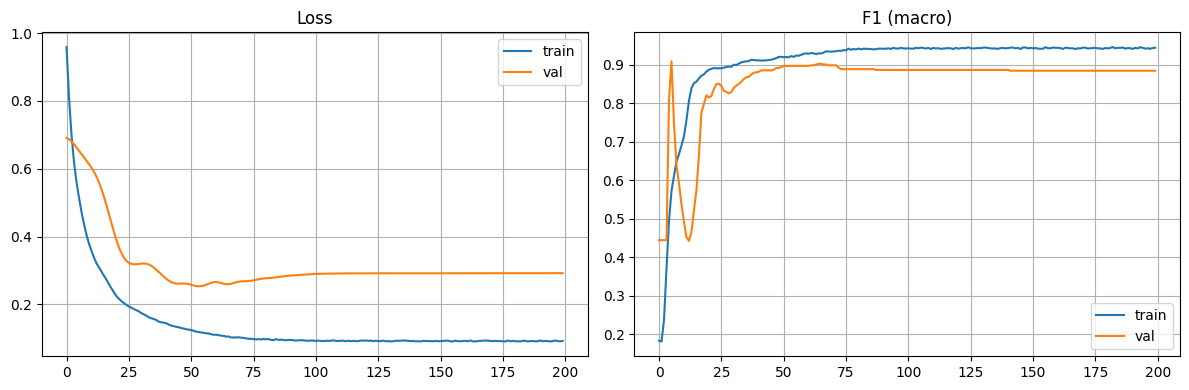

Training complete. Best val F1 = 0.9097 at epoch 6
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9720    0.9176    0.9440       680
           1     0.7308    0.8941    0.8042       170

    accuracy                         0.9129       850
   macro avg     0.8514    0.9059    0.8741       850
weighted avg     0.9237    0.9129    0.9161       850

Overall Accuracy: 0.9129
Macro Precision: 0.8514
Macro Recall:    0.9059
Macro F1:        0.8741
Fold 7: Train users: 41, Val users: 5, Test users: 5
Train windows: 6804, Val windows: 850, Test windows: 850
Class weights: tensor([0.6249, 2.5015])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:31<00:00,  6.42epoch/s, TL=0.125, VL=0.513, VF1=0.810, best VF1=0.821, best Epoch=22]


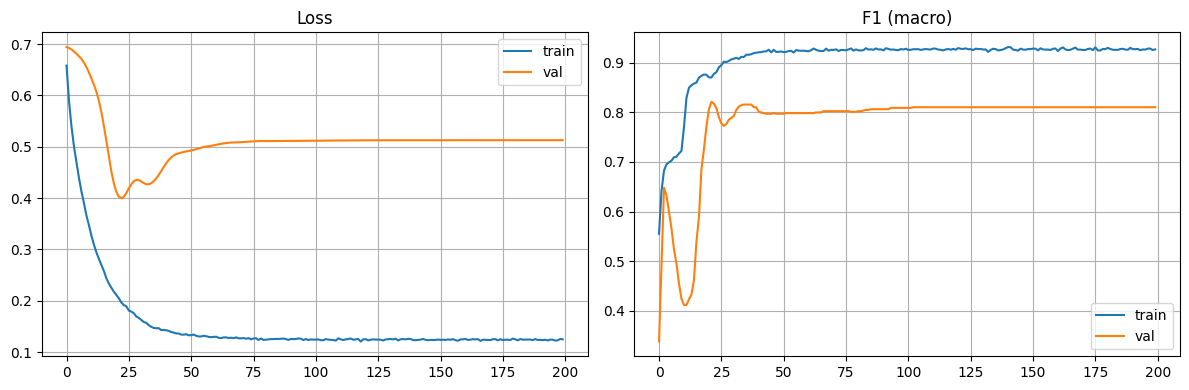

Training complete. Best val F1 = 0.8211 at epoch 22
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9918    0.8926    0.9396       680
           1     0.6933    0.9706    0.8088       170

    accuracy                         0.9082       850
   macro avg     0.8426    0.9316    0.8742       850
weighted avg     0.9321    0.9082    0.9135       850

Overall Accuracy: 0.9082
Macro Precision: 0.8426
Macro Recall:    0.9316
Macro F1:        0.8742
Macro F1: 0.9448






##################################################
Fold: 8
Fold 8: Train users: 41, Val users: 5, Test users: 5
Train windows: 6804, Val windows: 850, Test windows: 850
Class weights: tensor([0.6292, 2.4352])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:31<00:00,  6.38epoch/s, TL=0.031, VL=0.073, VF1=0.983, best VF1=0.983, best Epoch=156]


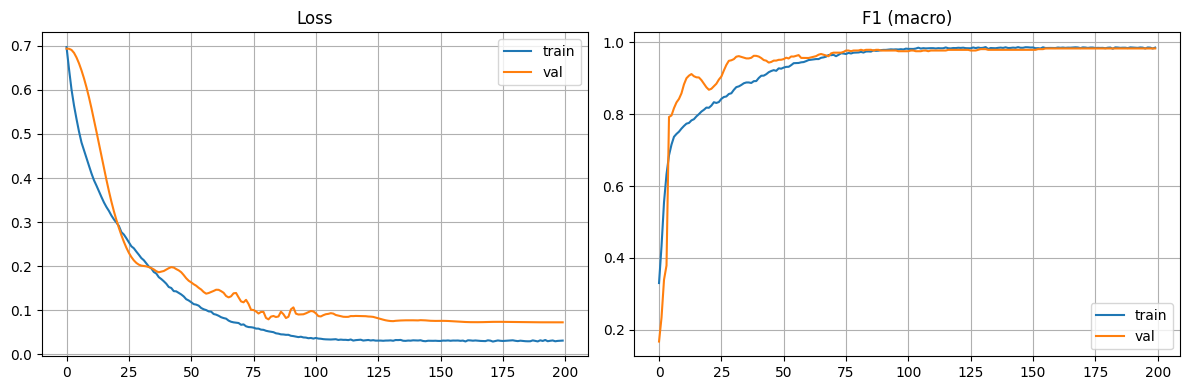

Training complete. Best val F1 = 0.9832 at epoch 156
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9700    0.9985    0.9841       680
           1     0.9933    0.8765    0.9313       170

    accuracy                         0.9741       850
   macro avg     0.9817    0.9375    0.9577       850
weighted avg     0.9747    0.9741    0.9735       850

Overall Accuracy: 0.9741
Macro Precision: 0.9817
Macro Recall:    0.9375
Macro F1:        0.9577
Fold 8: Train users: 41, Val users: 5, Test users: 5
Train windows: 6804, Val windows: 850, Test windows: 850
Class weights: tensor([0.6250, 2.4996])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:31<00:00,  6.43epoch/s, TL=0.005, VL=0.006, VF1=1.000, best VF1=1.000, best Epoch=17]


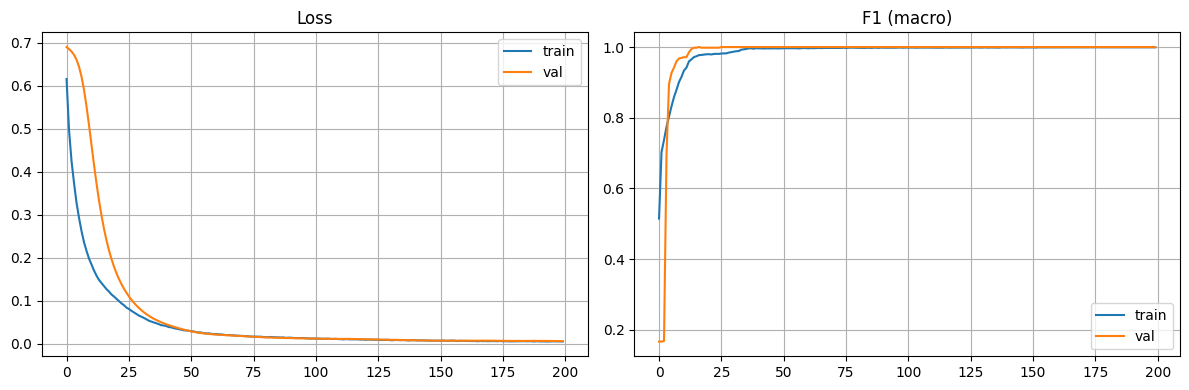

Training complete. Best val F1 = 1.0000 at epoch 17
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9927    1.0000    0.9963       680
           1     1.0000    0.9706    0.9851       170

    accuracy                         0.9941       850
   macro avg     0.9964    0.9853    0.9907       850
weighted avg     0.9942    0.9941    0.9941       850

Overall Accuracy: 0.9941
Macro Precision: 0.9964
Macro Recall:    0.9853
Macro F1:        0.9907
Fold 8: Train users: 41, Val users: 5, Test users: 5
Train windows: 6804, Val windows: 850, Test windows: 850
Class weights: tensor([0.6172, 2.6331])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:31<00:00,  6.27epoch/s, TL=0.046, VL=0.111, VF1=0.933, best VF1=0.954, best Epoch=142]


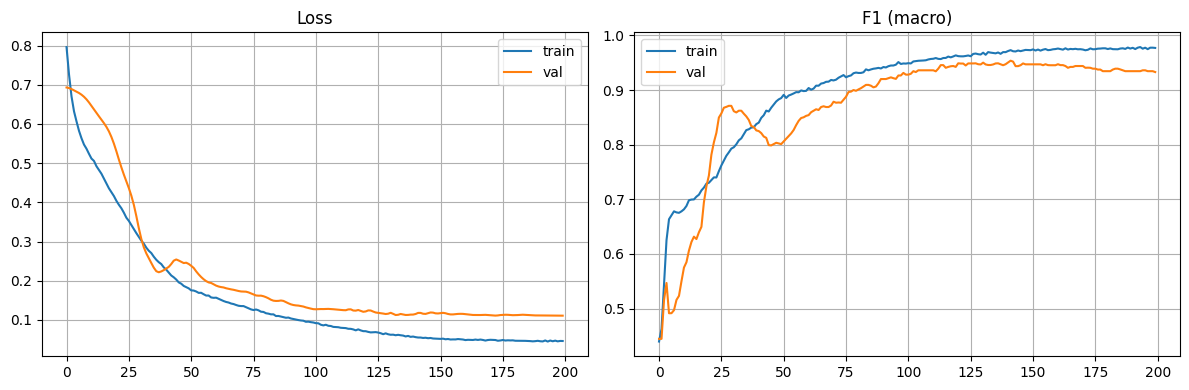

Training complete. Best val F1 = 0.9538 at epoch 142
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9969    0.9559    0.9760       680
           1     0.8485    0.9882    0.9130       170

    accuracy                         0.9624       850
   macro avg     0.9227    0.9721    0.9445       850
weighted avg     0.9672    0.9624    0.9634       850

Overall Accuracy: 0.9624
Macro Precision: 0.9227
Macro Recall:    0.9721
Macro F1:        0.9445
Fold 8: Train users: 41, Val users: 5, Test users: 5
Train windows: 6804, Val windows: 850, Test windows: 850
Class weights: tensor([0.6288, 2.4405])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:31<00:00,  6.37epoch/s, TL=0.080, VL=0.154, VF1=0.880, best VF1=0.880, best Epoch=137]


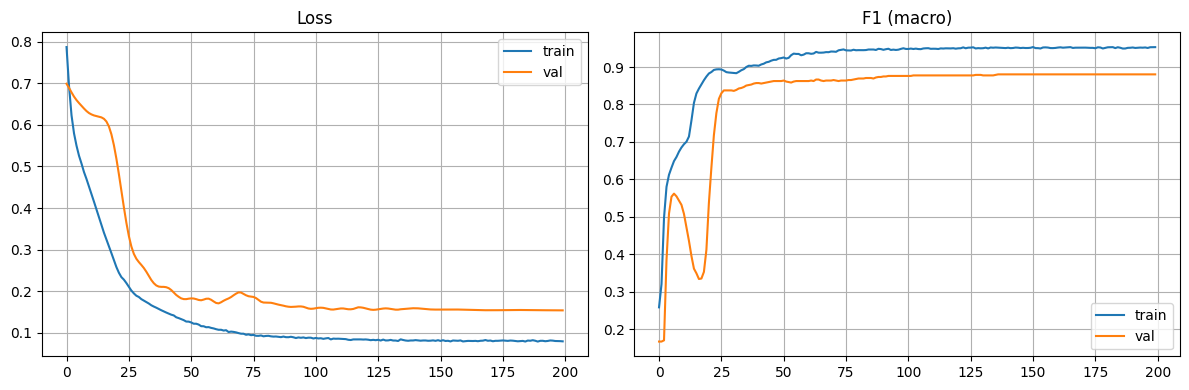

Training complete. Best val F1 = 0.8805 at epoch 137
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9654    0.9441    0.9546       680
           1     0.7946    0.8647    0.8282       170

    accuracy                         0.9282       850
   macro avg     0.8800    0.9044    0.8914       850
weighted avg     0.9312    0.9282    0.9294       850

Overall Accuracy: 0.9282
Macro Precision: 0.8800
Macro Recall:    0.9044
Macro F1:        0.8914
Fold 8: Train users: 41, Val users: 5, Test users: 5
Train windows: 6804, Val windows: 850, Test windows: 850
Class weights: tensor([0.6249, 2.5015])
Total trainable parameters: 4167


Training: 100%|████| 200/200 [00:31<00:00,  6.37epoch/s, TL=0.073, VL=0.152, VF1=0.890, best VF1=0.895, best Epoch=100]


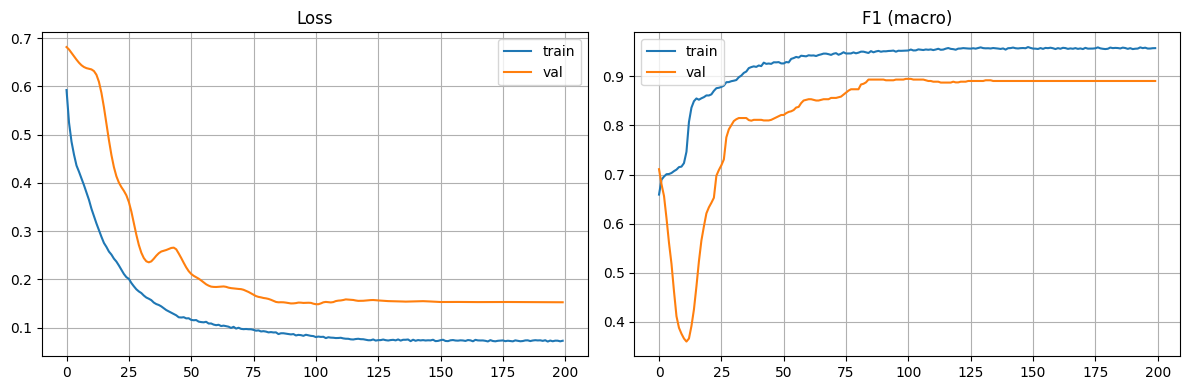

Training complete. Best val F1 = 0.8947 at epoch 100
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9473    0.9250    0.9360       680
           1     0.7258    0.7941    0.7584       170

    accuracy                         0.8988       850
   macro avg     0.8365    0.8596    0.8472       850
weighted avg     0.9030    0.8988    0.9005       850

Overall Accuracy: 0.8988
Macro Precision: 0.8365
Macro Recall:    0.8596
Macro F1:        0.8472
Macro F1: 0.8955






##################################################
Fold: 9
Fold 9: Train users: 40, Val users: 6, Test users: 5
Train windows: 6702, Val windows: 952, Test windows: 850
Class weights: tensor([0.6276, 2.4585])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:31<00:00,  6.31epoch/s, TL=0.057, VL=0.525, VF1=0.840, best VF1=0.875, best Epoch=58]


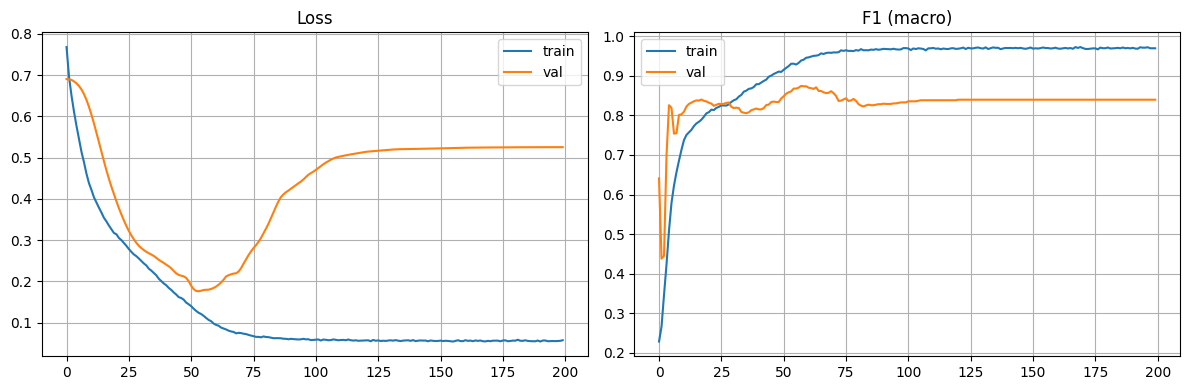

Training complete. Best val F1 = 0.8746 at epoch 58
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     0.9867    0.9838    0.9853       680
           1     0.9360    0.9471    0.9415       170

    accuracy                         0.9765       850
   macro avg     0.9614    0.9654    0.9634       850
weighted avg     0.9766    0.9765    0.9765       850

Overall Accuracy: 0.9765
Macro Precision: 0.9614
Macro Recall:    0.9654
Macro F1:        0.9634
Fold 9: Train users: 40, Val users: 6, Test users: 5
Train windows: 6702, Val windows: 952, Test windows: 850
Class weights: tensor([0.6234, 2.5252])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:30<00:00,  6.64epoch/s, TL=0.012, VL=0.046, VF1=0.984, best VF1=1.000, best Epoch=28]


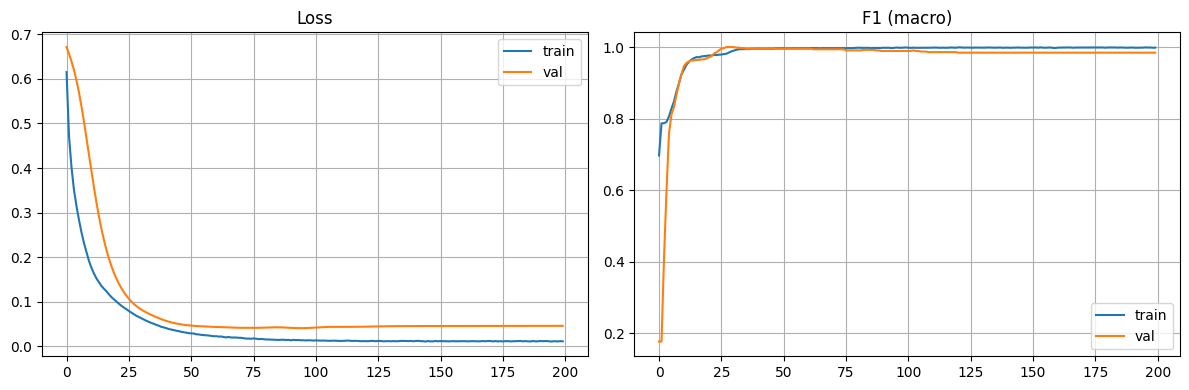

Training complete. Best val F1 = 1.0000 at epoch 28
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       680
           1     1.0000    1.0000    1.0000       170

    accuracy                         1.0000       850
   macro avg     1.0000    1.0000    1.0000       850
weighted avg     1.0000    1.0000    1.0000       850

Overall Accuracy: 1.0000
Macro Precision: 1.0000
Macro Recall:    1.0000
Macro F1:        1.0000
Fold 9: Train users: 40, Val users: 6, Test users: 5
Train windows: 6702, Val windows: 952, Test windows: 850
Class weights: tensor([0.6194, 2.5937])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:31<00:00,  6.40epoch/s, TL=0.083, VL=0.199, VF1=0.872, best VF1=0.902, best Epoch=64]


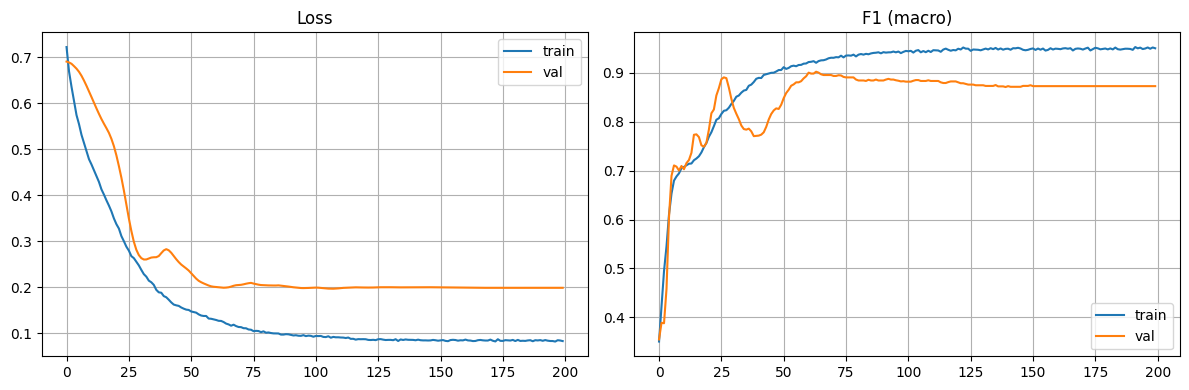

Training complete. Best val F1 = 0.9019 at epoch 64
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9015    0.9482       680
           1     0.7173    1.0000    0.8354       170

    accuracy                         0.9212       850
   macro avg     0.8586    0.9507    0.8918       850
weighted avg     0.9435    0.9212    0.9256       850

Overall Accuracy: 0.9212
Macro Precision: 0.8586
Macro Recall:    0.9507
Macro F1:        0.8918
Fold 9: Train users: 40, Val users: 6, Test users: 5
Train windows: 6702, Val windows: 952, Test windows: 850
Class weights: tensor([0.6273, 2.4640])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:31<00:00,  6.42epoch/s, TL=0.091, VL=0.437, VF1=0.778, best VF1=0.785, best Epoch=36]


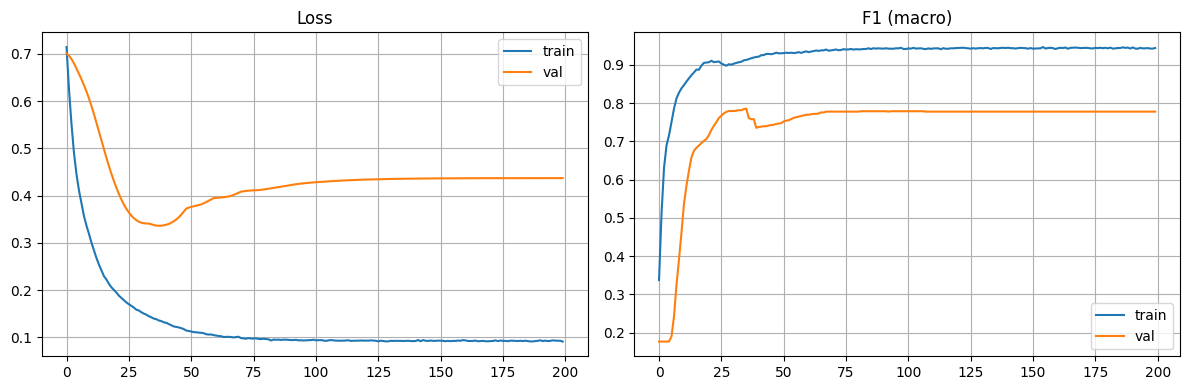

Training complete. Best val F1 = 0.7853 at epoch 36
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.9441    0.9713       680
           1     0.8173    1.0000    0.8995       170

    accuracy                         0.9553       850
   macro avg     0.9087    0.9721    0.9354       850
weighted avg     0.9635    0.9553    0.9569       850

Overall Accuracy: 0.9553
Macro Precision: 0.9087
Macro Recall:    0.9721
Macro F1:        0.9354
Fold 9: Train users: 40, Val users: 6, Test users: 5
Train windows: 6702, Val windows: 952, Test windows: 850
Class weights: tensor([0.6273, 2.4640])
Total trainable parameters: 4167


Training: 100%|█████| 200/200 [00:32<00:00,  6.20epoch/s, TL=0.101, VL=0.419, VF1=0.870, best VF1=0.872, best Epoch=70]


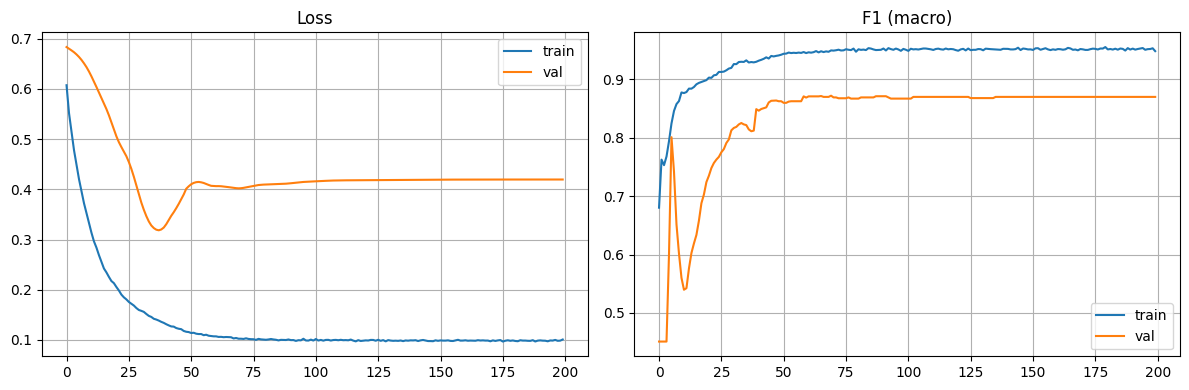

Training complete. Best val F1 = 0.8719 at epoch 70
Model saved to models/siddha_cnn.pt

========== Test Set Evaluation ==========
              precision    recall  f1-score   support

           0     1.0000    0.8853    0.9392       680
           1     0.6855    1.0000    0.8134       170

    accuracy                         0.9082       850
   macro avg     0.8427    0.9426    0.8763       850
weighted avg     0.9371    0.9082    0.9140       850

Overall Accuracy: 0.9082
Macro Precision: 0.8427
Macro Recall:    0.9426
Macro F1:        0.8763
Macro F1: 0.9529



Mean macro f1 for test users: 0.8909
std macro f1 for test users: 0.0586


In [5]:
# Train by folds

f1_list = []

for fold in range(n_splits):
    print('\n\n\n\n\n')
    print('#' * 50)
    print(f'Fold: {fold}')

    models = []
    X_test_scaled, y_test_initial = None, None

    for n_acr in range(5):
        
        model, X_test_scaled, y_test_initial = train_by_fold(fold, n_acr)
        models.append(model)

    f1 = evaluate_ensemble(models, X_test_scaled, y_test_initial)
    print(f"Macro F1: {f1:.4f}")
    f1_list.append(f1)

print(f'\n\n\nMean macro f1 for test users: {np.mean(f1_list):.4f}')
print(f'std macro f1 for test users: {np.std(f1_list):.4f}')